### Install Requirements

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install sdv

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer
from sdv.metadata import Metadata
SDV_API = "single_table"
# except Exception:
# raise ImportError("Please `pip install sdv` (and optional dependencies).")

In [3]:
!pip install -r /content/drive/MyDrive/Shell_AI_Hackathon/requirements.txt

  Using cached tabpfn_extensions-0.1.0-py3-none-any.whl


In [102]:
from huggingface_hub import hf_hub_download, snapshot_download
target_dir = "/content/drive/MyDrive/Shell_AI_Hackathon/models"

print("Downloading fold models from willieseun/Eagle-Team-TabPFN...")
for i in [2]:
    file_name = f"Fold_{i}_best_model.tabpfn_fit"
    model_path = hf_hub_download(
        repo_id="willieseun/Eagle-Team-TabPFN",
        filename=file_name,
        local_dir=target_dir
    )
    print(f"Downloaded: {model_path}")
# target_dir = "Models"
# Download full snapshot from wayne-chi/Eagle_Team
print("\nDownloading snapshot from wayne-chi/Eagle_Team...")
snapshot_download(
    repo_id="wayne-chi/Eagle_Team",
    revision="main",  # Optional, default is "main"
    local_dir=target_dir,
    local_dir_use_symlinks=False
)

Downloaded: /content/drive/MyDrive/Shell_AI_Hackathon/models/Fold_2_best_model.tabpfn_fit



/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

'/content/drive/MyDrive/Shell_AI_Hackathon/models'

In [90]:
import numpy as np
import pandas as pd
from tabpfn import TabPFNRegressor
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


train_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/train.csv')
test_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/test.csv')


# Define target columns
target_cols = [f"BlendProperty{i}" for i in range(1, 11)]

# # Apply feature engineering to both train and test data
# train_df_transformed, added_columns = create_blend_features(train_df)
# test_df_transformed, _ = create_blend_features(test_df)

train_df_transformed = train_df[:1600]
test_df_transformed = test_df


# Features and targets
X = train_df_transformed.drop(columns=target_cols).values
y = train_df[target_cols].values
sub = test_df_transformed.drop(columns=["ID"]).values

In [92]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from numpy.random import default_rng

rng = default_rng(42)

# ----- USER SETUP -----
df =  train_df_transformed.iloc[:,:-10]  # or however you have the data
prop_cols = df.columns[5:]  # replace with your 50 property column names
frac_cols = [f"Component{i}_fraction" for i in range(1, 6)]    # replace with your 5 fraction column names
# target_cols = [f"BlendProperty{i}" for i in range(1, 11)]             # replace or remove if not needed here

# Desired final multiplier (e.g., 50 for 50x)
desired_multiplier = 50

# Augmentation knobs (tune these)
neighbor_k = 5
jaccard_thresh = 0.7     # zero-pattern overlap threshold
dirichlet_kappa = 200.0  # higher -> less jitter; 100-400 is reasonable
max_attempts_per_row = 200 # safety cap

# ------------------------
# 1) train/val split (generate only from training)
# df_train, df_val_= train_test_split(df, test_size=0.02, random_state=42)
df_train = df

X_props = df_train[prop_cols].to_numpy()   # already standardized
F = df_train[frac_cols].to_numpy()
n_train = X_props.shape[0]

# Compute how many synthetic rows we need
total_target = int(n_train * desired_multiplier)
n_synth_needed = total_target - n_train
print(f"Original train rows: {n_train}, target total rows: {total_target}, synth needed: {n_synth_needed}")

if n_synth_needed <= 0:
    raise SystemExit("Multiplier <= 1. Nothing to do.")

# ----- helper functions -----
def zero_mask(frac_row, eps=1e-8):
    return (frac_row <= eps)

def jaccard_mask(a_mask, b_mask):
    inter = np.logical_and(a_mask, b_mask).sum()
    union = np.logical_or(a_mask, b_mask).sum()
    return inter / (union if union > 0 else 1)

def dirichlet_jitter(active_values, kappa, rng):
    # active_values: array of non-zero components that sum to 1
    # kappa: concentration; higher -> samples closer to active_values
    alpha = kappa * active_values
    # add tiny floor to alpha for numeric stability
    alpha = np.clip(alpha, 1e-6, None)
    return rng.dirichlet(alpha)

# ----- 2) build neighbor index on properties -----
knn = NearestNeighbors(n_neighbors=neighbor_k, metric="euclidean", n_jobs=-1)
knn.fit(X_props)

# ----- 3) augmentation loop -----
synth_rows = []
attempts = 0
generated = 0

# Precompute masks
F_masks = (F <= 1e-8)

# We'll generate roughly equal number of synthetic entries per original row,
# but use a loop that terminates when we reach n_synth_needed
row_idx = 0
while generated < n_synth_needed and attempts < max_attempts_per_row * n_train:
    attempts += 1
    i = row_idx % n_train
    p_row = X_props[i]          # property vector (kept unchanged)
    p_orig_frac = F[i]
    # neighbor indices (including itself)
    neigh_idx = knn.kneighbors(p_row.reshape(1,-1), return_distance=False)[0]
    # pick a neighbor at random (not necessarily i)
    j = int(rng.choice(neigh_idx))
    if j == i:
        # optionally pick a different one sometimes; allow self occasionally
        if rng.random() < 0.2:
            # allow same row (minor duplication)
            pass
        else:
            # try another
            j = int(rng.choice(neigh_idx))
    candidate_frac = F[j].copy()
    # Zero-pattern test: ensure mask overlap
    mask_i = F_masks[i]
    mask_j = F_masks[j]
    jac = jaccard_mask(mask_i, mask_j)
    if jac < jaccard_thresh:
        row_idx += 1
        continue

    # Optionally create a mixture of fractions from multiple neighbors:
    if rng.random() < 0.25:  # 25% of the time mix 2-3 neighbors
        # pick 1 or 2 extra neighbors
        extra = rng.choice(neigh_idx, size=rng.integers(1,3), replace=False)
        fracs = [F[k] for k in extra]
        weights = rng.random(len(fracs))
        weights = weights / weights.sum()
        # weighted average
        candidate_frac = np.sum([w * f for w,f in zip(weights, fracs)], axis=0)
        # enforce zeros if any component is zero across majority of selected neighbors
        zero_majority = np.mean([ (f <= 1e-8) for f in fracs ], axis=0) > 0.5
        candidate_frac[zero_majority] = 0.0

    # preserve zero positions exactly from candidate_frac: only jitter active components
    active = candidate_frac > 1e-8
    if active.sum() == 0:
        # degenerate: skip
        row_idx += 1
        continue

    # normalize active part to sum=1 then jitter via Dirichlet
    active_vals = candidate_frac[active].copy()
    active_vals = active_vals / active_vals.sum()
    new_active = dirichlet_jitter(active_vals, dirichlet_kappa, rng)
    new_frac = np.zeros_like(candidate_frac)
    new_frac[active] = new_active
    # final safety renormalize
    new_frac = new_frac / new_frac.sum()

    # optional dedupe check: skip if it already exists in training or previous synthetic set
    # quick hash
    key = tuple(np.round(new_frac, 6))
    # You may maintain a set of used fraction keys to avoid exact duplicates.
    # For speed we skip that here, but you probably want to dedupe in production.

    # append synthetic pair: property is p_row, fractions is new_frac
    synth_rows.append(np.concatenate([p_row, new_frac]))
    generated += 1
    row_idx += 1

print(f"Attempts: {attempts}, Generated synthetic rows: {generated}")

# Build DataFrame for synthetic rows
synth_arr = np.vstack(synth_rows)
synth_props = synth_arr[:, :len(prop_cols)]
synth_fracs = synth_arr[:, len(prop_cols):]

df_synth = pd.DataFrame(synth_props, columns=prop_cols)
for k, c in enumerate(frac_cols):
    df_synth[c] = synth_fracs[:, k]

# Combine with original train for labeling step
df_combined_for_labeling = pd.concat([df_train.reset_index(drop=True), df_synth], ignore_index=True)

# Save or pass df_combined_for_labeling to TabPFN labeling in batches
df_combined_for_labeling.to_csv("/content/drive/MyDrive/Shell_AI_Hackathon/to_label_with_tabpfn.csv", index=False)
df_synth.to_csv("/content/drive/MyDrive/Shell_AI_Hackathon/df_synth_trial2.csv", index=False)


Original train rows: 1600, target total rows: 80000, synth needed: 78400
Attempts: 320000, Generated synthetic rows: 33366


In [93]:
df_synth.shape

(33366, 55)

In [94]:
df_synth[:10].sample(10)

,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,Component1_Property2,Component2_Property2,Component3_Property2,Component4_Property2,Component5_Property2,...,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction
3,0.554659,-0.573588,0.866642,-0.668663,-2.007507,0.062367,-0.397305,0.389577,-1.238871,0.815614,...,0.613839,-0.500510,1.201379,-0.693737,-0.675878,0.000000,0.169715,0.288339,0.370278,0.171667
7,0.854607,1.163028,0.121952,-0.129812,-1.086446,-0.148459,-0.007976,0.069105,-0.447346,0.299109,...,0.206511,-0.150532,0.741344,1.343156,0.029956,0.173791,0.217480,0.000000,0.445425,0.163305
0,-0.577734,-0.930826,0.815284,0.447514,0.455717,-0.587815,1.962581,-1.147891,0.268938,0.207318,...,0.052972,-1.024785,0.118951,2.400556,-0.576430,0.248625,0.410563,0.000000,0.084471,0.256342
4,-1.076905,-0.308172,0.760629,0.237104,1.032029,-0.079604,-0.489310,-0.440306,-0.142072,0.056552,...,-0.217150,1.136293,2.102209,-0.284205,0.291568,0.146144,0.156042,0.177130,0.520684,0.000000
9,0.135721,0.560817,0.820580,1.007206,0.902769,-1.300621,1.100235,0.175929,-0.701907,-2.116479,...,-0.703697,0.259274,0.612816,-0.341612,1.561168,0.000000,0.199917,0.180882,0.483057,0.136144
2,-0.056714,0.642588,0.190996,-0.405550,1.032029,-0.093375,2.318643,-1.543739,-2.355227,0.367120,...,-0.197754,-0.955273,-0.828913,1.705019,-0.721963,0.362897,0.000000,0.156879,0.480224,0.000000
8,-0.401345,1.183811,-0.199984,-0.204758,1.032029,0.617136,0.741574,0.912965,-0.628323,-0.797869,...,-0.815993,0.838535,-1.011644,-0.498966,1.078485,0.231217,0.062758,0.188146,0.517879,0.000000
1,-1.370557,0.343101,-0.151224,0.022085,-1.087199,1.948975,0.320537,1.006811,0.431353,-0.291828,...,0.055218,1.038078,1.021289,0.961302,-0.099984,0.207210,0.000000,0.392170,0.260387,0.140232
6,0.422461,-0.641730,1.393210,1.151087,-0.841237,1.674541,1.281125,-0.197955,0.752538,0.513130,...,-1.875044,-0.933486,1.334687,-0.912597,1.726105,0.159213,0.000000,0.490856,0.226567,0.123363
5,0.007966,-0.101700,-0.059599,0.618247,0.455466,-0.970120,0.046083,0.845077,0.259989,-0.377436,...,-0.254106,1.482120,0.397387,0.610203,1.645716,0.202035,0.000000,0.290812,0.283027,0.224126


In [95]:
# Get column names
cols = df_synth.columns.tolist()

# Take last 5 columns and move them to the front
new_order = cols[-5:] + cols[:-5]

# Reorder DataFrame
df_synth1 = df_synth[new_order]

print(df_synth1.shape)
df_synth1.head()

(33366, 55)


,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
0,0.248625,0.410563,0.000000,0.084471,0.256342,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.534135,1.155513,-0.760428,0.450159,-0.973779,0.052972,-1.024785,0.118951,2.400556,-0.576430
1,0.207210,0.000000,0.392170,0.260387,0.140232,-1.370557,0.343101,-0.151224,0.022085,-1.087199,...,0.091440,0.467459,0.545014,-0.313594,-0.946204,0.055218,1.038078,1.021289,0.961302,-0.099984
2,0.362897,0.000000,0.156879,0.480224,0.000000,-0.056714,0.642588,0.190996,-0.405550,1.032029,...,1.847660,-0.995654,0.693743,0.389190,-0.110281,-0.197754,-0.955273,-0.828913,1.705019,-0.721963
3,0.000000,0.169715,0.288339,0.370278,0.171667,0.554659,-0.573588,0.866642,-0.668663,-2.007507,...,0.934416,-0.160435,-0.907832,-1.716700,0.079464,0.613839,-0.500510,1.201379,-0.693737,-0.675878
4,0.146144,0.156042,0.177130,0.520684,0.000000,-1.076905,-0.308172,0.760629,0.237104,1.032029,...,-1.737508,0.586127,1.315242,-0.927035,-1.290306,-0.217150,1.136293,2.102209,-0.284205,0.291568


In [99]:
df_synth1.isna().sum().sum()

0

In [1]:
import time

# 1. Instantiate your blend property prediction model
blend_model = EagleBlendPredictor()

# 2. Define your target properties
# target_blend_properties = np.array(train_df.iloc[2][-10:])


# 3. The 50 fixed inputs (component properties, etc.)
# input_df = df_combined_for_labeling[3000:3010]
input_df = df_synth1[:]
# input_df = train_df.iloc[5:6, :-10]
# input_df.iloc[0:1, :5] = [[0.1184, 0.1102, 0.223,  0.2644, 0.284]]

start = time.time()
predictions_df = blend_model.predict_all(input_df)
end = time.time()
duration = end-start
print(f"Complete at {duration:.2f} seconds")
# predicted_properties = predictions_df[self.output_columns].values.flatten()
predictions_df.to_csv("/content/drive/MyDrive/Shell_AI_Hackathon/targets_trial2.csv", index=False)
print(predictions_df.shape)
predictions_df.head()


NameError: name 'EagleBlendPredictor' is not defined

In [ ]:
predictions_df.isna().sum()

In [48]:
df_all = pd.concat([df_synth1, predictions_df], axis=1)
df_all.to_csv("/content/drive/MyDrive/Shell_AI_Hackathon/df_all.csv", index=False)
print(df_all.shape)
df_all.head()

(16176, 65)


,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.000000,0.011158,0.500968,0.398264,0.089610,-0.607111,-1.008338,0.083284,-1.306507,1.032029,...,0.444349,0.796326,1.462073,1.950653,-0.642858,1.059580,1.364904,0.527527,0.623867,0.429260
1,0.415170,0.131185,0.000000,0.321643,0.132002,0.911263,-1.481759,0.688588,1.202587,1.032029,...,0.657813,-0.217834,-0.501105,0.644558,0.333659,0.085177,-0.465046,1.427955,-0.884060,-0.279877
2,0.086941,0.171436,0.266267,0.475357,0.000000,0.370124,2.480907,1.110342,0.969733,0.751407,...,0.085463,0.503418,-0.088842,-0.895828,-0.398812,-1.625481,-0.055964,0.004291,-0.354890,0.448761
3,0.508123,0.000000,0.000000,0.491877,0.000000,-0.756591,1.206639,-0.580472,-0.001161,0.492804,...,-1.197447,-1.324829,0.718186,-0.811051,0.565336,0.848305,0.691817,-0.583236,0.000000,0.331924
4,0.474659,0.000000,0.139176,0.172756,0.213409,-0.997413,2.265065,0.507636,-0.961434,0.270366,...,0.484675,1.310974,0.977162,0.576274,1.707865,1.250771,0.911408,0.266751,2.113342,-0.001450


In [49]:
combined_df = pd.concat([train_df_transformed, df_all], axis=0, ignore_index=True)
combined_df.to_csv("/content/drive/MyDrive/Shell_AI_Hackathon/combined_df.csv", index=False)
print(combined_df.shape)
combined_df.head()

(17676, 65)


,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073


In [84]:
X_train = combined_df.iloc[:, :-10]
y_train = combined_df['BlendProperty9']
X_test = train_df.iloc[-500:, :-10]
y_test = train_df.iloc[-500:][["BlendProperty9"]].values.flatten()

In [89]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error
import numpy as np

# --- Train model ---
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Evaluation ---
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


R² Score: 0.9500
MAPE: 2.6958
MSE: 0.0523
RMSE: 0.2287


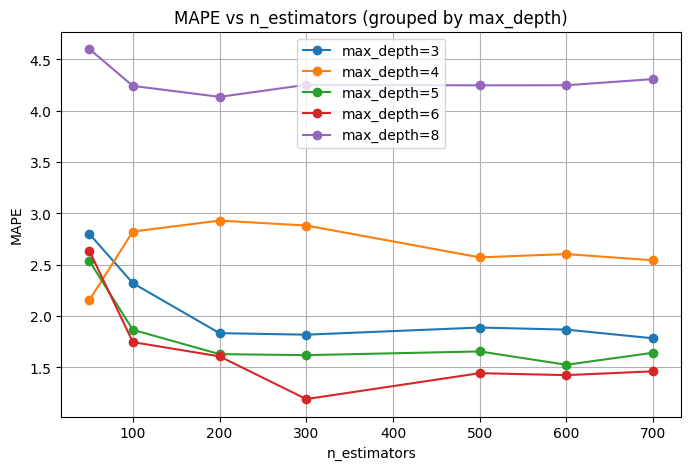

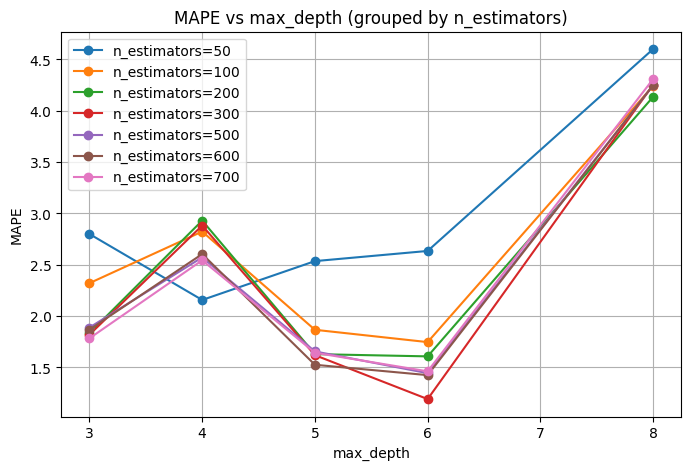

In [86]:
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

# --- Define parameter grid ---
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500, 600, 700],
    'max_depth': [3, 4, 5, 6, 8]
}

results = []

# --- Loop over parameter combinations ---
for params in ParameterGrid(param_grid):
    model = xgb.XGBRegressor(
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        **params
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, y_pred)
    results.append({"n_estimators": params["n_estimators"],
                    "max_depth": params["max_depth"],
                    "MAPE": mape})

# Convert results to DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

# --- Plot MAPE vs n_estimators ---
plt.figure(figsize=(8,5))
for depth in results_df["max_depth"].unique():
    subset = results_df[results_df["max_depth"] == depth]
    plt.plot(subset["n_estimators"], subset["MAPE"], marker="o", label=f"max_depth={depth}")
plt.xlabel("n_estimators")
plt.ylabel("MAPE")
plt.title("MAPE vs n_estimators (grouped by max_depth)")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot MAPE vs max_depth ---
plt.figure(figsize=(8,5))
for n_est in results_df["n_estimators"].unique():
    subset = results_df[results_df["n_estimators"] == n_est]
    plt.plot(subset["max_depth"], subset["MAPE"], marker="o", label=f"n_estimators={n_est}")
plt.xlabel("max_depth")
plt.ylabel("MAPE")
plt.title("MAPE vs max_depth (grouped by n_estimators)")
plt.legend()
plt.grid(True)
plt.show()


In [78]:
# !pip install optuna tensorflow

In [79]:
import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from optuna.importance import get_param_importances

# --- Safe MAPE (avoid divide by zero) ---
def safe_mape(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))

# --- Objective function for Optuna ---
def objective(trial):
    # Hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 4)
    units = [trial.suggest_int(f"units_l{i}", 32, 512, step=32) for i in range(n_layers)]
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    # Build ANN
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))
    for u in units:
        model.add(keras.layers.Dense(u, activation="relu"))
        model.add(keras.layers.Dropout(dropout))
    model.add(keras.layers.Dense(1))  # regression output

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse"   # train on MSE (smooth), select by MAPE
    )

    # Train
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    # Evaluate on validation
    val_pred = model.predict(X_test, verbose=0)
    mape_val = safe_mape(y_test, val_pred)
    return mape_val

# --- Run Optuna study ---
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best MAPE:", study.best_value)

# --- Train best model fully ---
best_params = study.best_params
n_layers = best_params["n_layers"]
units = [best_params[f"units_l{i}"] for i in range(n_layers)]
dropout = best_params["dropout"]
lr = best_params["lr"]
batch_size = best_params["batch_size"]

best_model = keras.Sequential()
best_model.add(keras.layers.Input(shape=(X_train.shape[1],)))
for u in units:
    best_model.add(keras.layers.Dense(u, activation="relu"))
    best_model.add(keras.layers.Dropout(dropout))
best_model.add(keras.layers.Dense(1))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss="mse"
)

best_model.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=1)

# --- Final evaluation ---
y_pred = best_model.predict(X_test, verbose=0)
mape = safe_mape(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test MAPE: {mape:.6f}")
print(f"Test MSE : {mse:.6f}")
print(f"Test RMSE: {rmse:.6f}")
print(f"Test R²  : {r2:.6f}")

# --- Analyze parameter importance ---
importances = get_param_importances(study)
top2 = list(importances.keys())[:2]
print("Top-2 important params:", top2)

# --- Plot MAPE vs param helper ---
def plot_param_vs_mape(param):
    trials_df = study.trials_dataframe()
    df = trials_df[trials_df["state"]=="Complete"][["value", f"params_{param}"]]
    df = df.dropna()

    grouped = df.groupby(f"params_{param}")["value"].median().reset_index()
    plt.figure(figsize=(7,4.5))
    plt.plot(grouped[f"params_{param}"], grouped["value"], marker="o")
    plt.xlabel(param)
    plt.ylabel("Median MAPE across trials")
    plt.title(f"MAPE vs {param}")
    plt.grid(True)
    plt.show()

for p in top2:
    plot_param_vs_mape(p)


[I 2025-08-25 02:49:51,717] A new study created in memory with name: no-name-9f9f4ace-12b3-455c-b307-5a5d19db2c5c


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-08-25 02:50:50,881] Trial 0 finished with value: 6.999115518912077 and parameters: {'n_layers': 2, 'units_l0': 512, 'units_l1': 384, 'dropout': 0.2993292420985183, 'lr': 0.0002051338263087451, 'batch_size': 64}. Best is trial 0 with value: 6.999115518912077.
[I 2025-08-25 02:51:47,868] Trial 1 finished with value: 6.76810636658065 and parameters: {'n_layers': 3, 'units_l0': 32, 'units_l1': 512, 'units_l2': 448, 'dropout': 0.10616955533913808, 'lr': 0.0002310201887845295, 'batch_size': 64}. Best is trial 1 with value: 6.76810636658065.
[W 2025-08-25 02:51:53,761] Trial 2 failed with parameters: {'n_layers': 2, 'units_l0': 320, 'units_l1': 96, 'dropout': 0.14607232426760908, 'lr': 0.0005404103854647331, 'batch_size': 32} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File 

KeyboardInterrupt: 

In [50]:
train_df_transformed.shape

(1500, 65)

In [40]:
# Check for duplicate rows
duplicates = predictions_df.duplicated()

# Count duplicate rows
num_duplicates = duplicates.sum()

print(f"Number of duplicate rows in predictions_df: {num_duplicates}")

# Optionally, display the duplicate rows
# if num_duplicates > 0:
#     print("\nDuplicate rows:")
#     display(predictions_df[duplicates])

Number of duplicate rows in predictions_df: 0


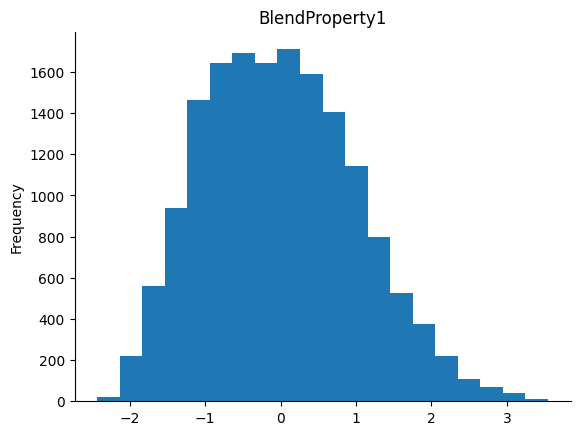

In [45]:
# @title BlendProperty1

from matplotlib import pyplot as plt
predictions_df['BlendProperty4'].plot(kind='hist', bins=20, title='BlendProperty1')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import pandas as pd

train_df = pd.read_csv(r'/content/drive/MyDrive/Shell_AI_Hackathon/train.csv')

train_df.head()

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,Component1_Property2,Component2_Property2,Component3_Property2,Component4_Property2,Component5_Property2,Component1_Property3,Component2_Property3,Component3_Property3,Component4_Property3,Component5_Property3,Component1_Property4,Component2_Property4,Component3_Property4,Component4_Property4,Component5_Property4,Component1_Property5,Component2_Property5,Component3_Property5,Component4_Property5,Component5_Property5,Component1_Property6,Component2_Property6,Component3_Property6,Component4_Property6,Component5_Property6,Component1_Property7,Component2_Property7,Component3_Property7,Component4_Property7,Component5_Property7,Component1_Property8,Component2_Property8,Component3_Property8,Component4_Property8,Component5_Property8,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,-1.229799,-0.580274,0.133998,0.817835,0.216116,-0.393322,0.221189,0.656104,0.074461,-3.082938,-1.763085,0.984515,-1.548115,-1.654290,-1.410049,0.051779,1.005824,-0.430868,1.743608,0.296713,-1.483333,-1.748359,1.503443,0.023043,1.741303,-0.509380,-0.468733,-1.317675,0.132155,0.221237,0.293815,-0.115753,-0.917992,-0.274704,0.513326,0.480368,1.044967,-0.450956,0.674572,-0.636394,-1.244963,-1.355050,-0.314423,0.993593,-2.728928,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,-1.075041,0.892835,1.363473,-1.743684,1.273144,-0.691084,-0.255620,1.270776,-0.333798,-2.086526,-1.869709,0.896234,-1.541202,-0.244737,-0.175381,-0.375340,1.081967,-0.017281,-1.913700,-0.436747,-0.222145,0.344109,0.703365,-0.737121,0.988643,-1.204671,0.795790,0.248477,0.366540,0.125072,0.948338,0.812621,-0.574724,-0.837602,0.636329,-1.958826,-0.019603,-0.807923,0.148715,1.439313,-1.160435,-0.014276,-0.135968,-1.221155,0.896222,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,0.240404,2.210005,-2.652413,-0.593851,-0.678255,-0.270626,1.434056,0.499405,-0.941673,1.437899,-3.062889,-0.278579,0.356307,0.480321,-0.047104,0.185845,-0.020313,-0.724472,-2.135805,-3.052837,-1.519468,-0.102943,0.613740,-0.591977,1.836633,0.020619,2.045834,-1.689579,-0.279133,-0.664966,-0.671136,0.397808,2.148911,-0.983115,1.039423,-0.798978,-0.444027,0.148405,-0.793607,0.123834,0.006829,0.668734,0.015449,-0.098661,-0.424314,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,-0.587815,1.962581,-1.147891,0.268938,0.207318,0.912940,-0.514868,0.217608,0.319216,-1.337976,0.734976,-0.231043,0.753782,0.992424,-0.970700,-0.238266,0.486113,1.234451,0.463316,1.066737,-1.145807,0.135888,-0.998752,0.911127,-0.261213,-0.539061,-1.559085,-0.631777,0.931398,-0.096509,0.754506,2.351753,-1.119210,-0.275574,-1.273487,-0.534135,1.155513,-0.760428,0.450159,-0.973779,0.052972,-1.024785,0.118951,2.400556,-0.576430,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,0.127614,-0.177430,-1.517532,0.114478,0.626086,1.342376,-0.006793,-0.370659,0.576510,0.115239,-0.580060,-1.079896,-1.330368,-1.522461,0.487384,0.638531,-0.143725,-0.239138,1.321531,1.566761,0.148538,0.282047,0.239846,0.420000,-1.

In [ ]:
import time

# 1. Instantiate your blend property prediction model
blend_model = EagleBlendPredictor()

# 2. Define your target properties
# target_blend_properties = np.array(train_df.iloc[2][-10:])


# 3. The 50 fixed inputs (component properties, etc.)
input = np.array(train_df.iloc[1:1, :-10]).flatten() # np.random.rand(50) # Using dummy data as in Code A example
input_df = train_df.iloc[5:6, :-10]
input_df.iloc[0:1, :5] = [[0.1184, 0.1102, 0.223,  0.2644, 0.284]]

start = time.time()
predictions_df = blend_model.predict_fast(input_df)
end = time.time()
duration = end-start
print(f"Complete at {duration:.2f} seconds")
# predicted_properties = predictions_df[self.output_columns].values.flatten()
print(predictions_df.shape)
predictions_df.head()


Initializing the TabPFN Ensemble Predictor...
Found 1 models to form the ensemble.
Loading model: Fold_2_best_model.tabpfn_fit...
Cuda is available
Successfully loaded Fold_2_best_model.tabpfn_fit
Complete at 10.97 seconds
(1, 6)


,BlendProperty1,BlendProperty2,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty10
0,1.699639,1.551331,-0.881725,1.709205,0.995537,0.971558


In [ ]:
input_df.head()

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,0.21,0.00,0.42,0.25,0.12,-0.021782,1.981251,0.020036,0.140315,1.032029,...,0.489143,0.607589,0.321670,-1.236055,1.601132,1.384662,0.305850,0.193460,0.580374,-0.762738
1,0.02,0.33,0.19,0.46,0.00,-0.224339,1.148036,-1.107840,0.149533,-0.354000,...,-1.257481,-1.475283,-0.437385,-1.402911,0.147941,-1.143244,-0.439171,-1.379041,-1.280989,-0.503625
2,0.08,0.08,0.18,0.50,0.16,0.457763,0.242591,-0.922492,0.908213,0.972003,...,1.784349,0.450467,0.622687,1.375614,-0.428790,1.161616,0.601289,0.872950,0.660000,2.024576
3,0.25,0.42,0.00,0.07,0.26,-0.577734,-0.930826,0.815284,0.447514,0.455717,...,-0.066422,0.483730,-1.865442,-0.046295,-0.163820,-0.209693,-1.840566,0.300293,-0.351336,-1.551914
4,0.26,0.16,0.08,0.50,0.00,0.120415,0.666268,-0.626934,2.725357,0.392259,...,-0.118913,-1.172398,0.301785,-1.787407,-0.493361,-0.528049,0.286344,-0.265192,0.430513,0.735073


In [ ]:
train_df.iloc[5:6, :5]

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction
5,0.5,0.0,0.0,0.5,0.0


In [ ]:
input_df = train_df.iloc[5:6, :-10]
input_df.iloc[0:1, :5] = [[0.1184, 0.1102, 0.223,  0.2644, 0.284]]
input_df

,Component1_fraction,Component2_fraction,Component3_fraction,Component4_fraction,Component5_fraction,Component1_Property1,Component2_Property1,Component3_Property1,Component4_Property1,Component5_Property1,...,Component1_Property9,Component2_Property9,Component3_Property9,Component4_Property9,Component5_Property9,Component1_Property10,Component2_Property10,Component3_Property10,Component4_Property10,Component5_Property10
5,0.1184,0.1102,0.223,0.2644,0.284,-1.126032,0.300001,-0.985341,-0.612353,0.111721,...,0.574467,-0.175991,-0.190113,0.692745,-0.392671,-0.001951,0.601643,-0.592482,0.278067,-0.752109


## Knowledge Distillation

In [ ]:
# train_df.iloc[:1000, :-10].to_csv('/content/drive/MyDrive/Shell_AI_Hackathon/trainZap.csv')

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm  # A library for smart progress bars
# from predictor import EagleBlendPredictor # Your predictor class

# --- 1. Setup ---
print("Loading the large dataset...")
# Load the full 200,000 row DataFrame
full_df = pd.read_csv('/content/synth_outputs/synthetic_tvae_200000.csv')

full_df = full_df.iloc[:, 1:]
print("Initializing predictor...")
# Initialize the predictor ONCE outside the loop
predictor = EagleBlendPredictor(model_sources='/content/drive/MyDrive/Shell_AI_Hackathon/models')

# --- 2. Mini-Batching Configuration ---
# Choose a batch size. Start with a power of 2 like 1024 or 2048.
# You will tune this based on your system's memory.
BATCH_SIZE = 2048
all_predictions = [] # An empty list to store prediction DataFrames

# --- 3. The Prediction Loop ---
print(f"Starting prediction with a batch size of {BATCH_SIZE}...")

# tqdm creates a progress bar for our loop
for i in tqdm(range(0, len(full_df), BATCH_SIZE)):
    # Get a slice of the DataFrame for the current batch
    batch_df = full_df.iloc[i : i + BATCH_SIZE]

    # Predict on the current mini-batch
    # The torch.no_grad() from our previous change will work its magic here
    batch_predictions = predictor.predict_all(batch_df)

    # Append the results of the batch to our list
    all_predictions.append(batch_predictions)

# --- 4. Combine Results ---
print("Combining all batch predictions...")
# Concatenate all the small prediction DataFrames into one large one
final_predictions_df = pd.concat(all_predictions, ignore_index=True)

print("Prediction on 200,000 rows complete!")
print(final_predictions_df.head())
print(f"Total rows predicted: {len(final_predictions_df)}")

# Optionally save the final results
# final_predictions_df.to_csv('final_predictions.csv', index=False)

Loading the large dataset...
Initializing predictor...
Initializing the TabPFN Ensemble Predictor...
Found 1 models to form the ensemble.
Loading model: Fold_2_best_model.tabpfn_fit...
Cuda is available
Successfully loaded Fold_2_best_model.tabpfn_fit
Starting prediction with a batch size of 2048...


  0%|          | 0/98 [00:00<?, ?it/s]

Processing input DataFrame...

Generating predictions from the model ensemble...
Using GPU with no_grad and autocast for optimized inference.


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


   - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


...

Processing input DataFrame...

Generating predictions from the model ensemble...
Using GPU with no_grad and autocast for optimized inference.
   - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


 24%|██▍       | 24/98 [47:10<2:25:12, 117.74s/it]/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processing input DataFrame...

Generating predictions from the model ensemble...
Using GPU with no_grad and autocast for optimized inference.
   - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


 26%|██▌       | 25/98 [49:08<2:23:09, 117.66s/it]/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processing input DataFrame...

Generating predictions from the model ensemble...
Using GPU with no_grad and autocast for optimized inference.


In [ ]:
# !pip -q install sdv pandas numpy scikit-learn scipy tqdm

### Dataset Generation

In [ ]:
# ---------------------- INSTALLS (Colab only, uncomment) ----------------------
# !pip install sdv torch pandas numpy scikit-learn tqdm

import os
import json
import time
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from scipy.stats import ks_2samp, wasserstein_distance, entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch

# === SDV modern API ===
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer
from sdv.metadata import Metadata

warnings.simplefilter("ignore", UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# ----------------------------- CONFIG ----------------------------------------
CONFIG = {
    "CSV_PATH": "/content/drive/MyDrive/Shell_AI_Hackathon/trainZap.csv",      # <-- Change: path to your CSV with 55 numeric features
    "TARGET_COLUMNS": [],             # leave empty: treat all columns as features
    "FEATURE_COLUMNS": None,
    "ALL_CONTINUOUS": True,

    "GENERATORS": ["GAUSSIAN_COPULA", "TVAE"],
    "SYNTHETIC_SIZE": 200000,
    "RANDOM_SEED": 42,

    "TVAE_PARAMS": {
        "epochs": 300,
        "batch_size": 512,
        "compress_dims": (256, 256),
        "decompress_dims": (256, 256),
        "embedding_dim": 128,
        "l2scale": 1e-6,
        "cuda": torch.cuda.is_available(),
        "verbose": True
    },

    "GAUSSIANCOPULA_PARAMS": {},

    "EVAL_SAMPLE_SIZE": 50000,
    "QC_TOPK": 10,
    "QUALITY_THRESHOLDS": {
        "KS_warn": 0.2,
        "WD_norm_warn": 0.1,
        "JS_warn": 0.1,
        "Corr_Frob_warn": 0.2,
        "RF_AUC_warn": 0.65,
        "MMD_warn": 0.1
    },

    "OUT_DIR": "synth_outputs",
}

os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)

# ----------------------------- Utilities -------------------------------------

def set_seed(seed=42):
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def load_data(path):
    assert os.path.exists(path), f"CSV not found: {path}"
    return pd.read_csv(path)

def infer_features(df, target_cols=None, feature_cols=None):
    target_cols = target_cols or []
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in target_cols]
    return df[feature_cols].copy(), feature_cols

def compute_ranges(X, overrides=None):
    overrides = overrides or {}
    rng = {}
    for col in X.columns:
        if pd.api.types.is_numeric_dtype(X[col]):
            lo = float(np.nanmin(X[col].values))
            hi = float(np.nanmax(X[col].values))
            rng[col] = (lo, hi)
    rng.update(overrides)
    return rng

def basic_impute_numeric(X):
    Xc = X.copy()
    for col in Xc.columns:
        if pd.api.types.is_numeric_dtype(Xc[col]):
            med = np.nanmedian(Xc[col].values)
            Xc[col] = Xc[col].fillna(med)
        else:
            Xc[col] = Xc[col].fillna("UNK")
    return Xc

# ----------------------- SDV Models ------------------------------------------

def train_gaussian_copula(X):
    metadata = Metadata.detect_from_dataframe(X)
    model = GaussianCopulaSynthesizer(metadata)
    t0 = time.time()
    model.fit(X)
    print(f"GaussianCopulaSynthesizer fit done in {(time.time()-t0)/60:.2f} min.")
    return model

def train_tvae(X, params):
    metadata = Metadata.detect_from_dataframe(X)
    model = TVAESynthesizer(
        metadata,
        epochs=params.get("epochs", 300),
        batch_size=params.get("batch_size", 512),
        compress_dims=params.get("compress_dims", (256, 256)),
        decompress_dims=params.get("decompress_dims", (256, 256)),
        embedding_dim=params.get("embedding_dim", 128),
        l2scale=params.get("l2scale", 1e-6),
        cuda=params.get("cuda", torch.cuda.is_available()),
        verbose=params.get("verbose", False)
    )
    t0 = time.time()
    model.fit(X)
    print(f"TVAESynthesizer fit done in {(time.time()-t0)/60:.2f} min.")
    return model

def sample_and_clip(model, n, feature_ranges, integer_cols=None, clip=True):
    S = model.sample(num_rows=n)
    for col in S.columns:
        if pd.api.types.is_numeric_dtype(S[col]) and clip and col in feature_ranges:
            lo, hi = feature_ranges[col]
            S[col] = S[col].clip(lower=lo, upper=hi)
    if integer_cols:
        for c in integer_cols:
            if c in S.columns:
                S[c] = np.round(S[c]).astype("Int64").astype(float)
                lo, hi = feature_ranges.get(c, (None, None))
                if lo is not None and hi is not None:
                    S[c] = S[c].clip(lower=math.ceil(lo), upper=math.floor(hi))
    return S

# ----------------------- Validation metrics ----------------------------------
# (unchanged from your version)
def jensen_shannon_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m) + entropy(q, m))

def numeric_hist_js(x, y, bins=50):
    lo = np.nanmin([np.min(x), np.min(y)])
    hi = np.nanmax([np.max(x), np.max(y)])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan
    px, _ = np.histogram(x, bins=bins, range=(lo, hi), density=True)
    py, _ = np.histogram(y, bins=bins, range=(lo, hi), density=True)
    return jensen_shannon_divergence(px, py)

def normalized_wasserstein(x, y):
    lo = np.nanmin([np.min(x), np.min(y)])
    hi = np.nanmax([np.max(x), np.max(y)])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return np.nan
    return wasserstein_distance(x, y) / (hi - lo)

def per_feature_report_numeric(real_df, synth_df, qc_topk=10):
    rows = []
    for col in real_df.columns:
        xr = pd.to_numeric(real_df[col], errors='coerce').dropna()
        xs = pd.to_numeric(synth_df[col], errors='coerce').dropna()
        if len(xr) == 0 or len(xs) == 0:
            ks = wd = js = np.nan
        else:
            ks = ks_2samp(xr, xs).statistic
            wd = normalized_wasserstein(xr, xs)
            js = numeric_hist_js(xr, xs)
        rows.append({"column": col, "KS": ks, "Wasserstein_norm": wd, "JS": js})
    df = pd.DataFrame(rows)
    print("\nTop drift by KS:")
    print(df.sort_values("KS", ascending=False).head(qc_topk)[["column", "KS"]])
    print("\nTop drift by Wasserstein_norm:")
    print(df.sort_values("Wasserstein_norm", ascending=False).head(qc_topk)[["column", "Wasserstein_norm"]])
    print("\nTop drift by JS:")
    print(df.sort_values("JS", ascending=False).head(qc_topk)[["column", "JS"]])
    return df

def corr_frobenius_diff(real_df, synth_df):
    num_cols = [c for c in real_df.columns if pd.api.types.is_numeric_dtype(real_df[c])]
    if not num_cols:
        return {"pearson_frob": np.nan, "spearman_frob": np.nan}
    rr = real_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")
    ss = synth_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")
    Cr = rr.corr(method="pearson").fillna(0).to_numpy()
    Cs = ss.corr(method="pearson").fillna(0).to_numpy()
    Spr = rr.corr(method="spearman").fillna(0).to_numpy()
    Sps = ss.corr(method="spearman").fillna(0).to_numpy()
    pear = np.linalg.norm(Cr - Cs, ord="fro") / Cr.size
    spear = np.linalg.norm(Spr - Sps, ord="fro") / Spr.size
    return {"pearson_frob": pear, "spearman_frob": spear}

def gaussian_mmd(X, Y, sigma=None, max_samples=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    if len(X) > max_samples:
        X = X[rng.choice(len(X), max_samples, replace=False)]
    if len(Y) > max_samples:
        Y = Y[rng.choice(len(Y), max_samples, replace=False)]
    scaler = StandardScaler()
    XY = np.vstack([X, Y])
    XY = scaler.fit_transform(XY)
    Xs, Ys = XY[:len(X)], XY[len(X):]
    if sigma is None:
        Z = np.vstack([Xs[:1000], Ys[:1000]]) if len(Xs) > 1000 and len(Ys) > 0 else np.vstack([Xs, Ys])
        dists = np.sum((Z[:, None, :] - Z[None, :, :]) ** 2, axis=2)
        med = np.median(dists[np.triu_indices_from(dists, k=1)])
        sigma = max(np.sqrt(med / 2), 1e-6)
    def k(a, b):
        return np.exp(-np.sum((a[:, None, :] - b[None, :, :]) ** 2, axis=2) / (2 * sigma ** 2))
    Kxx = k(Xs, Xs)
    Kyy = k(Ys, Ys)
    Kxy = k(Xs, Ys)
    n, m = len(Xs), len(Ys)
    mmd2 = (Kxx.sum() - np.trace(Kxx)) / (n*(n-1)) \
         + (Kyy.sum() - np.trace(Kyy)) / (m*(m-1)) \
         - 2*Kxy.mean()
    return float(np.sqrt(max(mmd2, 0.0)))

def classifier_two_sample_auc(real_df, synth_df, random_state=42):
    X = pd.concat([real_df, synth_df], axis=0).copy()
    y = np.array([0] * len(real_df) + [1] * len(synth_df))
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    transformers = []
    if num_cols:
        transformers.append(("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols))
    pre = ColumnTransformer(transformers=transformers, remainder="drop")
    X_proc = pre.fit_transform(X)
    clf = RandomForestClassifier(n_estimators=300, random_state=random_state, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    aucs = cross_val_score(clf, X_proc, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return float(aucs.mean())

# ----------------------------- Runner ----------------------------------------

def run_pipeline(config):
    set_seed(config["RANDOM_SEED"])
    df = load_data(config["CSV_PATH"])
    X, feat_cols = infer_features(df, target_cols=config["TARGET_COLUMNS"], feature_cols=config["FEATURE_COLUMNS"])
    print(f"Loaded data {df.shape}; using {len(feat_cols)} features (first 8): {feat_cols[:8]}")

    X_clean = basic_impute_numeric(X)
    feature_ranges = compute_ranges(X_clean)
    print("Sample feature ranges (first 8):")
    for i, (k, v) in enumerate(list(feature_ranges.items())[:8]):
        print(f"  {k}: {v}")

    results_summary = {}

    for gen_name in config["GENERATORS"]:
        print("\n" + "=" * 80)
        print(f"RUN GENERATOR: {gen_name}")
        print("=" * 80)

        if gen_name == "GAUSSIAN_COPULA":
            model = train_gaussian_copula(X_clean)
        elif gen_name == "TVAE":
            model = train_tvae(X_clean, config["TVAE_PARAMS"])
        else:
            raise ValueError("Unknown generator: " + str(gen_name))

        n = int(config["SYNTHETIC_SIZE"])
        print(f"Sampling {n:,} rows from {gen_name} ...")
        S = sample_and_clip(model, n, feature_ranges, integer_cols=None, clip=True)
        S = S[feat_cols]

        out_csv = os.path.join(config["OUT_DIR"], f"synthetic_{gen_name.lower()}_{n:,}.csv".replace(",", ""))
        S.to_csv(out_csv, index=False)
        print(f"Saved synthetic CSV: {out_csv}")

        eval_n = min(config["EVAL_SAMPLE_SIZE"], len(S))
        S_eval = S.sample(eval_n, random_state=config["RANDOM_SEED"])
        X_eval = X_clean.sample(eval_n, random_state=config["RANDOM_SEED"])

        per_feat = per_feature_report_numeric(X_eval, S_eval, qc_topk=config["QC_TOPK"])
        per_feat_csv = os.path.join(config["OUT_DIR"], f"drift_per_feature_{gen_name.lower()}.csv")
        per_feat.to_csv(per_feat_csv, index=False)

        corr_stats = corr_frobenius_diff(X_eval, S_eval)
        try:
            auc = classifier_two_sample_auc(X_eval, S_eval, random_state=config["RANDOM_SEED"])
        except Exception as e:
            print("Classifier test failed:", e)
            auc = float("nan")

        num_cols_eval = [c for c in X_eval.columns if pd.api.types.is_numeric_dtype(X_eval[c])]
        if num_cols_eval:
            Xn = X_eval[num_cols_eval].to_numpy(dtype=float)
            Sn = S_eval[num_cols_eval].to_numpy(dtype=float)
            mmd = gaussian_mmd(Xn, Sn, sigma=None, max_samples=5000, random_state=config["RANDOM_SEED"])
        else:
            mmd = float("nan")

        print("\nSUMMARY for", gen_name)
        print(f"  Worst KS: {float(per_feat['KS'].max()):.4f}")
        print(f"  Worst Wasserstein_norm: {float(per_feat['Wasserstein_norm'].max()):.4f}")
        print(f"  Worst JS: {float(per_feat['JS'].max()):.4f}")
        print(f"  Pearson corr Frobenius diff: {corr_stats['pearson_frob']:.4f}")
        print(f"  Spearman corr Frobenius diff: {corr_stats['spearman_frob']:.4f}")
        print(f"  Classifier AUC: {auc:.4f}")
        print(f"  MMD: {mmd:.4f}")

        results_summary[gen_name] = {
            "synthetic_csv": out_csv,
            "per_feature_csv": per_feat_csv,
            "per_feature_stats": per_feat.to_dict(orient="records"),
            "corr_stats": corr_stats,
            "two_sample_auc": float(auc),
            "mmd": float(mmd),
        }

        summary_path = os.path.join(config["OUT_DIR"], f"summary_{gen_name.lower()}.json")
        with open(summary_path, "w") as f:
            json.dump(results_summary[gen_name], f, indent=2)
        print(f"Saved summary JSON: {summary_path}")

    combined_path = os.path.join(config["OUT_DIR"], "combined_summaries.json")
    with open(combined_path, "w") as f:
        json.dump(results_summary, f, indent=2)
    print(f"\nAll generator runs complete. Combined summary saved to: {combined_path}")
    return results_summary

# ----------------------------- Execute ---------------------------------------
if __name__ == "__main__":
    if not os.path.exists(CONFIG["CSV_PATH"]):
        raise SystemExit(f"Please set CONFIG['CSV_PATH'] to your dataset CSV (current: {CONFIG['CSV_PATH']})")
    results = run_pipeline(CONFIG)


Loaded data (1000, 56); using 56 features (first 8): ['Unnamed: 0', 'Component1_fraction', 'Component2_fraction', 'Component3_fraction', 'Component4_fraction', 'Component5_fraction', 'Component1_Property1', 'Component2_Property1']
Sample feature ranges (first 8):
  Unnamed: 0: (0.0, 999.0)
  Component1_fraction: (0.0, 0.5)
  Component2_fraction: (0.0, 0.5)
  Component3_fraction: (0.0, 0.5)
  Component4_fraction: (0.01, 0.5)
  Component5_fraction: (0.0, 0.29)
  Component1_Property1: (-2.933245035, 2.981145936)
  Component2_Property1: (-1.718895404, 2.910546032)

RUN GENERATOR: GAUSSIAN_COPULA
GaussianCopulaSynthesizer fit done in 0.08 min.
Sampling 200,000 rows from GAUSSIAN_COPULA ...
Saved synthetic CSV: synth_outputs/synthetic_gaussian_copula_200000.csv

Top drift by KS:
                   column     KS
0              Unnamed: 0  0.999
51  Component1_Property10  0.609
15   Component5_Property2  0.394
10   Component5_Property1  0.277
20   Component5_Property3  0.256
1     Component1_f

/tmp/ipython-input-2249277529.py:209: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rr = real_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")
/tmp/ipython-input-2249277529.py:210: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ss = synth_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")



SUMMARY for GAUSSIAN_COPULA
  Worst KS: 0.9990
  Worst Wasserstein_norm: 0.5000
  Worst JS: 0.6439
  Pearson corr Frobenius diff: 0.0007
  Spearman corr Frobenius diff: 0.0007
  Classifier AUC: 1.0000
  MMD: 0.1599
Saved summary JSON: synth_outputs/summary_gaussian_copula.json

RUN GENERATOR: TVAE


Loss: 69.616: 100%|██████████| 300/300 [00:36<00:00,  8.33it/s]


TVAESynthesizer fit done in 1.10 min.
Sampling 200,000 rows from TVAE ...
Saved synthetic CSV: synth_outputs/synthetic_tvae_200000.csv

Top drift by KS:
                  column     KS
0             Unnamed: 0  0.999
10  Component5_Property1  0.558
46  Component1_Property9  0.312
1    Component1_fraction  0.272
7   Component2_Property1  0.265
2    Component2_fraction  0.265
43  Component3_Property8  0.255
40  Component5_Property7  0.252
3    Component3_fraction  0.227
25  Component5_Property4  0.209

Top drift by Wasserstein_norm:
                  column  Wasserstein_norm
0             Unnamed: 0          0.500000
10  Component5_Property1          0.186738
1    Component1_fraction          0.157360
2    Component2_fraction          0.144080
3    Component3_fraction          0.131820
7   Component2_Property1          0.125898
46  Component1_Property9          0.115903
40  Component5_Property7          0.108372
25  Component5_Property4          0.099933
15  Component5_Property2         

/tmp/ipython-input-2249277529.py:209: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rr = real_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")
/tmp/ipython-input-2249277529.py:210: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ss = synth_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(method="ffill")



SUMMARY for TVAE
  Worst KS: 0.9990
  Worst Wasserstein_norm: 0.5000
  Worst JS: 0.6439
  Pearson corr Frobenius diff: 0.0014
  Spearman corr Frobenius diff: 0.0014
  Classifier AUC: 1.0000
  MMD: 0.2281
Saved summary JSON: synth_outputs/summary_tvae.json

All generator runs complete. Combined summary saved to: synth_outputs/combined_summaries.json


### Optimizations

In [ ]:
import numpy as np
import pandas as pd
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

# --- Components from Code A (or your actual project) ---
# Ensure EagleBlendPredictor is defined or imported here.
# For demonstration, a placeholder class is included.
# class EagleBlendPredictor:
#     """
#     This class should be your actual, trained model.
#     It must have a 'predict_df' method that accepts a DataFrame.
#     """
#     def predict_df(self, df: pd.DataFrame) -> pd.DataFrame:
#         # Dummy prediction logic: replace with your model's actual call
#         # e.g., return pd.DataFrame(self.model.predict(df), columns=output_cols)
#         num_rows = len(df)
#         # Create a dummy output that is sensitive to the inputs
#         # This simulates a model responding to the 5 variable fractions
#         blend_properties = np.zeros((num_rows, 10))
#         fractions = df.iloc[:, :5].values
#         for i in range(10):
#             # Make each property a slightly different combination of fractions
#             blend_properties[:, i] = np.sum(fractions * np.random.rand(5), axis=1) * (i + 5)
#         return pd.DataFrame(blend_properties, columns=[f'BlendProperty{i+1}' for i in range(10)])

def calculate_cost(fractions_df: pd.DataFrame) -> np.ndarray:
    """
    Cost function that takes a DataFrame of the variable fractions.
    (Copied directly from Code A)
    """
    component_costs = np.array([10.5, 12.0, 9.8, 15.2, 11.5])
    # Use dot product on the underlying numpy arrays for efficiency
    return fractions_df.values @ component_costs

# --- End of Imported Components ---


class BlendOptimizationProblem(Problem):
    """
    This class defines the optimization problem for pymoo.
    It preserves the structure of Code B but is adapted for the
    data handling of Code A.
    """
    def __init__(self,
                 blend_model,
                 target_properties: np.ndarray,
                 fixed_inputs: np.ndarray,
                 input_columns: list,
                 output_columns: list,
                 optimize_cost=False):

        self.blend_model = blend_model
        self.target_properties = target_properties
        self.fixed_inputs = fixed_inputs
        self.input_columns = input_columns
        self.output_columns = output_columns
        self.optimize_cost = optimize_cost

        # Determine the number of objectives
        n_obj = 2 if self.optimize_cost else 1

        super().__init__(
            n_var=5,        # 5 component fractions
            n_obj=n_obj,      # 1 or 2 objectives
            n_constr=1,       # 1 constraint (fractions must sum to 1)
            xl=0.0,         # Lower bound for each fraction is 0
            xu=1.0          # Upper bound for each fraction is 1
        )

    def _evaluate(self, x, out, *args, **kwargs):
        # 'x' is a numpy array of solutions from the GA population.
        # Each row in 'x' is one potential solution (a set of 5 fractions).

        # --- Constraint Handling ---
        # The sum of fractions must be 1. We enforce this here.
        sum_of_fractions = np.sum(x, axis=1, keepdims=True)
        # Avoid division by zero if a solution is all zeros
        sum_of_fractions[sum_of_fractions == 0] = 1
        normalized_fractions = x / sum_of_fractions

        # This sets the constraint violation. We want sum(x) - 1 to be 0.
        # Note: In Code A this was `np.abs(sum_of_fractions.flatten() - 1.0)`.
        # Preserving Code B's original `sum_of_fractions - 1.0` approach.
        g1 = sum_of_fractions - 1.0
        out["G"] = g1

        # --- Objective Calculation ---
        # Prepare arrays to store the results for each solution in the population
        f1_errors = np.zeros(len(normalized_fractions))

        if self.optimize_cost:
            f2_costs = np.zeros(len(normalized_fractions))

        # Calculate objectives for each solution (maintaining Code B's loop)
        for i, single_solution_fractions in enumerate(normalized_fractions):
            # --- ADAPTATION FOR CODE A's DATA STRUCTURE ---
            # 1. Construct the full 55-feature input for the model for this single solution
            full_input_data = np.hstack([single_solution_fractions, self.fixed_inputs])

            # 2. Create the DataFrame the model expects
            input_df = pd.DataFrame([full_input_data], columns=self.input_columns)

            # 3. Get predicted properties from your model
            predictions_df = self.blend_model.predict_df(input_df)
            predicted_properties = predictions_df[self.output_columns].values.flatten()

            # 4. Calculate Objective 1: Sum of Squared Errors
            error = np.sum((predicted_properties - self.target_properties)**2)
            f1_errors[i] = error

            # 5. (Optional) Calculate Objective 2: Cost
            if self.optimize_cost:
                # The cost function expects a DataFrame of fractions
                fractions_df = input_df.iloc[:, :5]
                cost = calculate_cost(fractions_df)[0] # result is an array, get the single value
                f2_costs[i] = cost

        # Set the output for the optimizer
        if self.optimize_cost:
            out["F"] = np.column_stack([f1_errors, f2_costs])
        else:
            out["F"] = f1_errors


if __name__ == '__main__':
    # --- Configuration (using data setup from Code A) ---
    # 1. Instantiate your blend property prediction model
    blend_model = EagleBlendPredictor()

    # 2. Define your target properties
    target_blend_properties = np.array(train_df.iloc[2][-10:]) #np.array([8.5, 10.2, 7.0, 12.5, 6.0, 4.5, 5.5, 80.0, 5.0, 4.0])

    # 3. The 50 fixed inputs (component properties, etc.)
    fixed_model_inputs = np.array(train_df.iloc[1:2, 5:-10]).flatten() # np.random.rand(50) # Using dummy data as in Code A example

    # 4. Define the column names for your model's input DataFrame
    variable_cols = df.columns[:5].to_list()  # Assuming first 5 columns are variable fractions
    fixed_cols = df.columns[5:55].to_list()  # Assuming next 50 columns are fixed inputs
    input_cols = variable_cols + fixed_cols
    output_cols = [f'BlendProperty{i+1}' for i in range(10)]

    # 5. Decide if you want to include cost in the optimization
    INCLUDE_COST = True

    # --- Setup and Run Optimization (structure from Code B) ---
    # 6. Initialize the problem definition with all required data
    problem = BlendOptimizationProblem(
        blend_model=blend_model,
        target_properties=target_blend_properties,
        fixed_inputs=fixed_model_inputs,
        input_columns=input_cols,
        output_columns=output_cols,
        optimize_cost=INCLUDE_COST
    )

    # 7. Configure the NSGA-II algorithm
    algorithm = NSGA2(
        pop_size=100,      # Population size - how many solutions to test at once
        eliminate_duplicates=True
    )

    # 8. Run the optimization
    print("🚀 Starting Optimization...")
    res = minimize(
        problem,
        algorithm,
        termination=('n_gen', 20), # Stop after 200 generations
        seed=1,
        verbose=True # Set to False for less console output
    )
    print("✅ Optimization Finished!")

    # --- Analyze Results (structure from Code B) ---
    print("\n--- Results ---")
    if res.X is not None and len(res.X) > 0:
        if INCLUDE_COST:
            # For multi-objective, res.X contains the Pareto front of solutions
            print(f"Found {len(res.X)} optimal trade-off solution(s).")
            # Show the best solution in terms of property error (as in Code A)
            best_by_error_idx = np.argmin(res.F[:, 0])
            best_solution = res.X[best_by_error_idx]
            best_objectives = res.F[best_by_error_idx]

            normalized_sol = best_solution / np.sum(best_solution)
            print("\n🏆 Best Solution (by smallest property error):")
            print(f"   Fractions: {np.round(normalized_sol, 4)}")
            print(f"   Property Error (Objective 1): {best_objectives[0]:.4f}")
            print(f"   Cost (Objective 2): {best_objectives[1]:.2f}")

            # Plot the Pareto Front
            plot = Scatter(title="Pareto Front: Error vs. Cost", labels=["Property Error", "Cost"])
            plot.add(res.F)
            plot.show()

        else:
            # For single-objective, we have one best solution
            print("Found best solution:")
            normalized_sol = res.X / np.sum(res.X)
            print(f"   Fractions: {np.round(normalized_sol, 3)}")
            print(f"   Property Error: {res.F[0]:.4f}")
    else:
        print("No solution found.")

Initializing the TabPFN Ensemble Predictor...
Found 1 models to form the ensemble.
Loading model: Fold_2_best_model.tabpfn_fit...
Cuda is available
Successfully loaded Fold_2_best_model.tabpfn_fit
🚀 Starting Optimization...
Processing input DataFrame...

Generating predictions from the model ensemble...


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


  - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processing input DataFrame...

Generating predictions from the model ensemble...
  - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


...

Processing input DataFrame...

Generating predictions from the model ensemble...
  - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processing input DataFrame...

Generating predictions from the model ensemble...
  - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Processing input DataFrame...

Generating predictions from the model ensemble...


### New Optimization

In [ ]:
# !pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.9/295.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.7 MB/s eta 0:00:00


Initializing the TabPFN Ensemble Predictor...
Found 1 models to form the ensemble.
Loading model: Fold_2_best_model.tabpfn_fit...
Cuda is available
Successfully loaded Fold_2_best_model.tabpfn_fit
🚀 Starting Optimization (optimizing for fast properties only)...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  0.0301787834 |  3.8850429175 |             - |             -
     2 |      200 |      1 |  0.0301787834 |  1.2370290744 |             - |             -
     3 |      300 |      1 |  0.0097072821 |  0.5779435761 |             - |             -
     4 |      400 |      1 |  0.0097072821 |  0.3637493129 |             - |             -
     5 |      500 |      1 |  0.0097072821 |  0.2428299499 |             - |             -
     6 |      600 |      1 |  0.0097072821 |  0.1742289639 |             - |             -
     7 |      700 |      1 |  0.0097072821 |  0.1403307776 |             - |             -
     8 |  

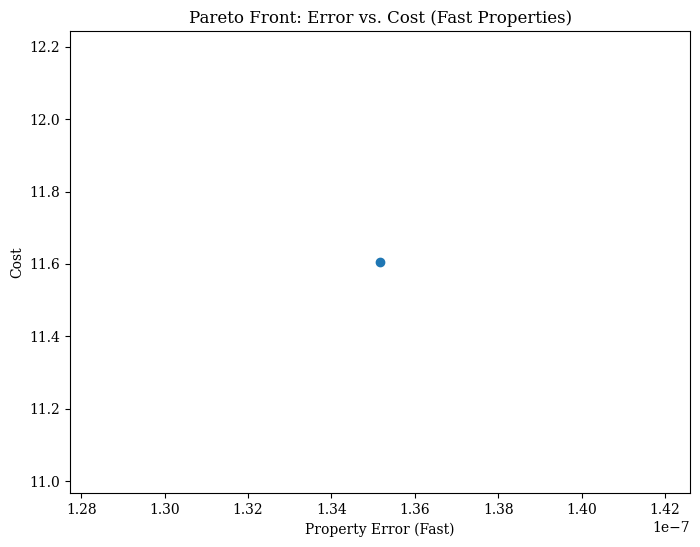

In [ ]:
import numpy as np
import pandas as pd
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
import time
import warnings
warnings.filterwarnings('ignore')

# (Your EagleBlendOptimizer and calculate_cost functions remain the same)
# class EagleBlendOptimizer:
#     """Dummy class simulating your model (accepts/returns DataFrames)."""
#     def predict_all(self, input_df: pd.DataFrame) -> pd.DataFrame:
#         # Your real model logic here...
#         # This is just a placeholder to make the code runnable.
#         output_data = {'Prop' + str(i+1): np.random.rand(len(input_df)) for i in range(10)}
#         return pd.DataFrame(output_data)

def calculate_cost(fractions_df: pd.DataFrame) -> np.ndarray:
    """Dummy cost function."""
    component_costs = np.array([10.5, 12.0, 9.8, 15.2, 11.5])
    return fractions_df.values @ component_costs


# --- IMPROVEMENT: A dedicated operator to handle the sum-to-one constraint ---
class NormalizationRepair(Repair):
    """
    A Repair operator that ensures the first 5 variables (fractions)
    in a solution always sum to 1. This is more efficient than
    treating it as a formal constraint during selection.
    """
    def _do(self, problem, X, **kwargs):
        # The input X is a matrix of solutions
        # Get the first 5 columns (the fractions)
        fractions = X[:, :5]

        # Calculate the sum of each row, preventing division by zero
        row_sums = np.sum(fractions, axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 # Avoid division by zero

        # Normalize the fractions
        normalized_fractions = fractions / row_sums

        # Update the solutions in place
        X[:, :5] = normalized_fractions

        return X


class BlendOptimizationProblem(Problem):
    def __init__(self,
                 blend_model,
                 target_properties: np.ndarray,
                 fixed_inputs: np.ndarray,
                 frozen_targets: dict,
                 input_columns: list,
                 output_columns: list, # Now corresponds to the columns returned by predict_fast
                 optimize_cost=False):

        self.blend_model = blend_model
        self.target_properties = target_properties # Still need full targets to potentially select from
        self.fixed_inputs = fixed_inputs
        self.frozen_targets = frozen_targets
        self.input_columns = input_columns
        self.output_columns = output_columns # List of column names from predict_fast
        self.optimize_cost = optimize_cost
        self.is_empty = True if not frozen_targets else False

        # --- Constraint Handling ---
        # Constraints are only for frozen properties. Sum-to-one is handled by Repair.
        n_constraints = len(self.frozen_targets)

        n_obj = 2 if self.optimize_cost else 1

        super().__init__(
            n_var=5,
            n_obj=n_obj,
            n_constr=n_constraints if n_constraints > 0 else 1,
            xl=0.0,
            xu=1.0
        )

        self.epsilon = 1e-3

        # --- Adjusting objectives and constraints for predict_fast ---
        # The indices of the *predicted* properties that correspond to frozen targets
        self.frozen_indices_predicted = [self.output_columns.index(f'BlendProperty{k}') for k in self.frozen_targets.keys() if f'BlendProperty{k}' in self.output_columns]
        self.frozen_values = np.array([v for k, v in self.frozen_targets.items() if f'BlendProperty{k}' in self.output_columns])

        # The mask for the *predicted* properties that are NOT frozen (these are the objectives)
        self.objective_mask_predicted = np.ones(len(self.output_columns), dtype=bool)
        if self.frozen_indices_predicted:
             self.objective_mask_predicted[self.frozen_indices_predicted] = False

        # The target values for the properties that are objectives
        # Need to map the original target indices to the indices in the output_columns
        all_output_property_indices = [int(col.replace('BlendProperty', '')) for col in self.output_columns]
        self.objective_targets = np.array([
            self.target_properties[prop_idx - 1] # -1 because target_properties is 0-indexed
            for i, prop_idx in enumerate(all_output_property_indices)
            if self.objective_mask_predicted[i]
        ])


    def _evaluate(self, x, out, *args, **kwargs):
        # NOTE: The fractions 'x' are already normalized by the Repair operator,
        # so we can use them directly.

        # 1. Construct the full DataFrame for the model
        fixed_data = np.tile(self.fixed_inputs, (len(x), 1))
        full_input_data = np.hstack([x, fixed_data])
        input_df = pd.DataFrame(full_input_data, columns=self.input_columns)

        # 2. Get predictions (using predict_fast)
        predictions_df = self.blend_model.predict_fast(input_df)
        # Ensure predictions_df has the correct columns in the correct order
        predicted_properties = predictions_df[self.output_columns].values

        # 3. Calculate objectives
        # Use the mask specifically created for the predicted properties
        if self.is_empty:
            error = np.sum((predicted_properties[:, self.objective_mask_predicted] - self.objective_targets)**2, axis=1)
        else:
            error = np.sum((predicted_properties[:, self.frozen_indices_predicted] - self.frozen_values)**2, axis=1)
        if self.optimize_cost:
            cost = calculate_cost(input_df.iloc[:, :5])
            out["F"] = np.column_stack([error, cost])
        else:
            out["F"] = error

        # 4. Calculate constraints (ONLY for frozen properties predicted by predict_fast)
        if self.frozen_targets and self.frozen_indices_predicted:
             frozen_violations = np.abs(predicted_properties[:, self.frozen_indices_predicted] - self.frozen_values) - self.epsilon
             out["G"] = frozen_violations
        elif self.frozen_targets and not self.frozen_indices_predicted:
             # Frozen targets were provided but are not among the 'fast' properties.
             # This shouldn't happen with the current logic, but as a fallback,
             # return a dummy constraint violation indicating they can't be met via predict_fast.
             # A large positive number signifies a significant violation.
             out["G"] = np.full((len(x), len(self.frozen_targets)), 1e6) # Large violation for each specified frozen target
        else:
            # If there are no constraints, return a value of 0 (no violation).
            out["G"] = np.zeros(len(x))


# input = np.array(train_df.iloc[1:1, :-10]).flatten() # np.random.rand(50) # Using dummy data as in Code A example
# input_df = train_df.iloc[8:9, :-10]

# --- 1. SETUP (same as before) ---
blend_model = EagleBlendPredictor()
fixed_model_inputs = np.array(train_df.iloc[5:6, 5:-10]).flatten() #np.random.rand(50)
# input_cols = [f'frac_{i+1}' for i in range(5)] + [f'param_{i+1}' for i in range(50)]
input_cols = train_df.iloc[:, :-10].columns.to_list()
# Update output_cols to include ONLY the 6 properties returned by predict_fast
output_cols = [f'BlendProperty{i}' for i in [1,2,5,6,7,10]]
# Keep full_target_properties as it contains the values for all 10 properties
full_target_properties = np.array([0.85, 1.2, 2.0, 1.25, 0.6, 0.45, 1.5, 0.80, 2.5, 1.0])


# --- 2. CONFIGURE THE RUN ---

# Use an empty dictionary to run without freezing any properties.
# This should now work correctly and behave like your first script.
frozen_targets_to_use = {1:1.7, 2:1.7}

# Example with frozen targets (must be one of the 6 fast properties):
# frozen_targets_to_use = {2: 0.5, 7: 0.1}

INCLUDE_COST = True

# --- 3. SETUP AND RUN ---
problem = BlendOptimizationProblem(
    blend_model=blend_model,
    target_properties=full_target_properties, # Pass the full targets
    fixed_inputs=fixed_model_inputs,
    frozen_targets=frozen_targets_to_use,
    input_columns=input_cols,
    output_columns=output_cols, # Pass only the fast output column names
    optimize_cost=INCLUDE_COST
)

# --- IMPROVEMENT: Add the Repair operator to the algorithm ---
algorithm = NSGA2(
    pop_size=100,
    repair=NormalizationRepair(), # This automatically fixes the fractions
    eliminate_duplicates=True
)
start = time.time()
print("🚀 Starting Optimization (optimizing for fast properties only)...")
res = minimize(
    problem,
    algorithm,
    termination=('n_gen', 20),
    seed=1,
    verbose=True
)
end = time.time()
print(f"Time taken: {end - start} seconds")

# --- 4. ANALYZE RESULTS (same as before) ---
print("\n--- ✅ Optimization Finished ---")
if res.X is not None and len(res.X) > 0:
    print(f"Found {len(res.X)} optimal trade-off solution(s).")
    if INCLUDE_COST:
        # For multi-objective, res.X contains the Pareto front of solutions
        print(f"Found {len(res.X)} optimal trade-off solution(s).")
        # Show the best solution in terms of property error (as in Code A)
        best_by_error_idx = np.argmin(res.F[:, 0])
        best_solution = res.X[best_by_error_idx]
        best_objectives = res.F[best_by_error_idx]

        normalized_sol = best_solution / np.sum(best_solution)
        print("\n🏆 Best Solution (by smallest property error for fast properties):")
        print(f"   Fractions: {np.round(normalized_sol, 4)}")
        print(f"   Property Error (Objectives 1, 2, 5, 6, 7, 10): {best_objectives[0]:.4f}")
        print(f"   Cost (Objective 2): {best_objectives[1]:.2f}")

        # Plot the Pareto Front
        plot = Scatter(title="Pareto Front: Error vs. Cost (Fast Properties)", labels=["Property Error (Fast)", "Cost"])
        plot.add(res.F)
        plot.show()

    else:
        # For single-objective, we have one best solution
        print("Found best solution:")
        normalized_sol = res.X / np.sum(res.X)
        print(f"   Fractions: {np.round(normalized_sol, 3)}")
        print(f"   Property Error (Objectives 1, 2, 5, 6, 7, 10): {res.F[0]:.4f}")

else:
    print("No feasible solution was found. If you are freezing properties, consider relaxing your constraints.")


--- Results ---
Found 1 optimal trade-off solution(s) on the Pareto Front.

--- Solution #1 ---
   Fractions: [0.1831 0.061  0.2616 0.1897 0.3045]
   Property Error (Objective 1): 0.0004
   Cost (Objective 2): 11.60


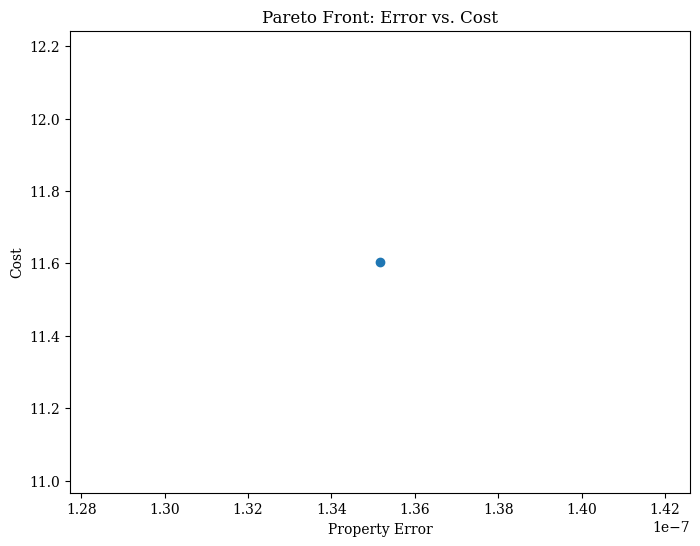

In [ ]:
# --- Analyze Results (MODIFIED to show all solutions) ---
print("\n--- Results ---")
if res.X is not None and len(res.X) > 0:
    if INCLUDE_COST:
        print(f"Found {len(res.X)} optimal trade-off solution(s) on the Pareto Front.")

        # Loop through every solution found
        for i, (solution, objectives) in enumerate(zip(res.X, res.F)):
            # res.X contains the 5 fractions for a solution
            # res.F contains the [error, cost] objectives for that solution

            normalized_sol = solution / np.sum(solution)

            print(f"\n--- Solution #{i+1} ---")
            print(f"   Fractions: {np.round(normalized_sol, 4)}")
            print(f"   Property Error (Objective 1): {objectives[0]**0.5:.4f}")
            print(f"   Cost (Objective 2): {objectives[1]:.2f}")

        # The plot of the Pareto Front will still show
        plot = Scatter(title="Pareto Front: Error vs. Cost", labels=["Property Error", "Cost"])
        plot.add(res.F)
        plot.show()

In [ ]:
import time

# 1. Instantiate your blend property prediction model
blend_model = EagleBlendPredictor()

# 2. Define your target properties

In [ ]:
# [0.2469 0.0632 0.2083 0.1643 0.3173]

In [ ]:

# target_blend_properties = np.array(train_df.iloc[2][-10:])


# 3. The 50 fixed inputs (component properties, etc.)
input = np.array(train_df.iloc[1:1, :-10]).flatten() # np.random.rand(50) # Using dummy data as in Code A example
input_df = train_df.iloc[5:6, :-10]
input_df.iloc[0:1, :5] = [res.X[0]]

start = time.time()
predictions_df = blend_model.predict_all(input_df)
end = time.time()
duration = end-start
print(f"Complete at {duration:.2f} seconds")
# predicted_properties = predictions_df[self.output_columns].values.flatten()
print(predictions_df.shape)
predictions_df.head()


Processing input DataFrame...

Generating predictions from the model ensemble...
Using GPU with no_grad and autocast for optimized inference.
   - Prediction from model 1 completed.

Averaging predictions from all models...
Ensemble prediction complete.
Complete at 53.55 seconds
(1, 10)


,BlendProperty1,BlendProperty2,BlendProperty3,BlendProperty4,BlendProperty5,BlendProperty6,BlendProperty7,BlendProperty8,BlendProperty9,BlendProperty10
0,1.699825,1.699615,1.13375,2.983533,-0.882037,1.981752,1.330804,0.66814,1.456144,0.548279


## Predictor.py

In [5]:
# prompt: import pandas and basic machine learning models for regression

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


from sklearn.model_selection import train_test_split

import itertools
import random

import torch
import random
import numpy as np

import os
import joblib

import matplotlib.pyplot as plt

from tabpfn import TabPFNRegressor
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression

# from inference import TabPFNEnsemblePredictor  # import inference.py

# from sklearn.metrics import mean_absolute_percentage_error
# from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor
from itertools import combinations
from scipy.special import comb
# from tabpfn.model.loading import (
#     load_fitted_tabpfn_model,
#     save_fitted_tabpfn_model,
# )


class EagleBlendPredictor:
    def __init__(self, model_sources = '/content/drive/MyDrive/Shell_AI_Hackathon/models'):
        """
        model_sources: Dict[str, Any]
            A dictionary where keys are 'BlendProperty1', ..., 'BlendProperty10'
            and values are:
              - loaded model objects, or
              - callables returning models, or
              - custom loading logic (you will supply these)
        """
        self.home = model_sources
        self.saved_files_map = {
                      1: {
                          "model": 'linear_model_poly_target_1.joblib',
                          "transform": 'poly1_features.joblib'
                      },
                      2: {
                          "model": 'linear_model_poly_target_2.joblib',
                          "transform": 'poly2_features.joblib'
                      },
                      5: {
                          "model": 'tabpfn_model_target_5.joblib', #tabpfn_model_target_5_cpu.tabpfn_fit,'tabpfn_model_target_5_cpu.tabpfn_fit'
                          "transform": 'poly5_features.joblib'
                      },
                      6: {
                          "model": 'linear_model_poly_target_6.joblib',
                          "transform": 'poly6_features.joblib'
                      },
                      7: {
                          "model": 'tabpfn_model_target_7.joblib',
                          # For Property 7, the transformation is the mixture feature generation,
                          # which is not a saved object like PolynomialFeatures.
                          # You would need to apply the generate_mixture_features function.
                          "transform_function": "generate_mixture_features"
                      },
                      8: {
                          # For Property 8, the "model" is the initial prediction model (not explicitly saved in this workflow)
                          # and the correction is the piecewise function defined by parameters and threshold.
                          "params": 'piecewise_params_prop8.joblib',
                          "threshold": 'piecewise_threshold_prop8.joblib',
                          "correction_function": "piecewise_model" # Reference the function name
                      },
                      10: {
                          "model": 'linear_model_poly_target_10.joblib',
                          "transform": 'poly10_features.joblib'
                      }
                  }


        self.models = {}
        # Load models and transformers manually
        self.model_1 = joblib.load(os.path.join(self.home, self.saved_files_map[1]["model"]))
        self.poly_1 = joblib.load(os.path.join(self.home, self.saved_files_map[1]["transform"]))

        self.model_2 = joblib.load(os.path.join(self.home, self.saved_files_map[2]["model"]))
        self.poly_2 = joblib.load(os.path.join(self.home, self.saved_files_map[2]["transform"]))

        self.model_5 = joblib.load(
            os.path.join(self.home, self.saved_files_map[5]["model"]), #device="cpu"
        )
        self.poly_5 = joblib.load(os.path.join(self.home, self.saved_files_map[5]["transform"]))

        self.model_6 = joblib.load(os.path.join(self.home, self.saved_files_map[6]["model"]))
        self.poly_6 = joblib.load(os.path.join(self.home, self.saved_files_map[6]["transform"]))

        self.model_7 = joblib.load(
            os.path.join(self.home, self.saved_files_map[7]["model"]), #device="cpu"
        )
        # No saved transform for model_7 — use generate_mixture_features later in prediction
        self.piecewise_params_8 = joblib.load(os.path.join(self.home, self.saved_files_map[8]["params"]))
        self.piecewise_threshold_8 = joblib.load(os.path.join(self.home, self.saved_files_map[8]["threshold"]))

        # Use piecewise_model function later

        self.model_10 = joblib.load(os.path.join(self.home, self.saved_files_map[10]["model"]))
        self.poly_10 = joblib.load(os.path.join(self.home, self.saved_files_map[10]["transform"]))

        self.model_3489 = TabPFNEnsemblePredictor(model_dir=self.home)
        pass


    def piecewise_model(self, x, boundaries=np.linspace(-0.2, 0.2, 10+1)[1:-1]):
        """
        x: a single float value
        params: list of 20 parameters [A1, B1, A2, B2, ..., A10, B10]
        boundaries: 9 values that divide x into 10 regions
        """
        params = self.piecewise_params_8
        # Unpack parameters
        segments = [(params[i], params[i+1]) for i in range(0, 20, 2)]

        # Piecewise logic using boundaries
        for i, bound in enumerate(boundaries):
            if x < bound:
                A, B = segments[i]
                return A * x + B
        # If x is greater than all boundaries, use the last segment
        A, B = segments[-1]
        return A * x + B

    def predict_BlendProperty1(self, data, full = True):
        # Dummy custom transformation and prediction for BlendProperty1
        if full:
            features = self._transform1(data)
            features = self.poly_1.transform(features)
        else:
            features = self.poly_1.transform(data)
        res_df = self.model_1.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty1'])


    def predict_BlendProperty2(self, data, full = True):
        if full:
            features = self._transform2(data)
            features = self.poly_2.transform(features)
        else:
            features = self.poly_2.transform(data)
        res_df = self.model_2.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty2'])


    def predict_BlendProperty3489(self, df):
        arrray,result_df = self.model_3489.custom_predict(df)
        ans_df= result_df[['BlendProperty3','BlendProperty4','BlendProperty8','BlendProperty9']].copy() # Explicitly create a copy

        ans_df.loc[ans_df['BlendProperty8'].abs()<0.2,'BlendProperty8'] = ans_df[ans_df['BlendProperty8'].abs()<0.2]['BlendProperty8'].apply(self.piecewise_model)
        ans_df.loc[ans_df['BlendProperty9'].abs()<0.1,'BlendProperty9'] = 0 #ans_df[ans_df['BlendProperty8'].abs()<0.2]['BlendProperty8'].apply(self.piecewise_model)

        return ans_df

        # ndf.loc[ndf[pred_col].abs() < threshold_8, pred_col] = ndf[ndf[pred_col].abs() < threshold_8][pred_col].apply(func8)

    def predict_BlendProperty5(self, data, full =True ):
        if full:
            features = self._transform5(data)
            features = self.poly_5.transform(features)
        else:
            features = self.poly_5.transform(data)
        res_df = self.model_5.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty5'])


    def predict_BlendProperty6(self, data, full=True):
        if full:
            features = self._transform6(data)
            features = self.poly_6.transform(features)
        else:
            features = self.poly_6.transform(data)
        res_df = self.model_6.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty6'])


    def predict_BlendProperty7(self, data, full =True)-> pd.DataFrame:
        if full:
            features = self._transform7(data)
        else:
            raise ValueError("BlendProperty7 prediction requires full data.")
        res_df = self.model_7.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty7'])


    def predict_BlendProperty10(self, data, full = False)-> pd.DataFrame:
        if full:
            features = self._transform10(data)
            features = self.poly_10.transform(features)
        else:
            features = self.poly_10.transform(data)
        res_df = self.model_10.predict(features)
        return pd.DataFrame(res_df, columns=['BlendProperty10'])


    def predict_all(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Generates predictions for all blend properties using the individual prediction methods.

        Args:
            df: Input DataFrame containing the features.

        Returns:
            DataFrame with predicted blend properties from 'BlendProperty1' to 'BlendProperty10'.
        """
        predictions_list = []

        # Predict individual properties
        predictions_list.append(self.predict_BlendProperty1(df, full=True))
        predictions_list.append(self.predict_BlendProperty2(df, full=True))

        # Predict BlendProperty3, 4, 8, and 9 together using predict_BlendProperty3489
        # Assuming predict_BlendProperty3489 returns a DataFrame with columns for these properties.
        predictions_3489_df = self.predict_BlendProperty3489(df)
        predictions_list.append(predictions_3489_df[['BlendProperty3']])
        predictions_list.append(predictions_3489_df[['BlendProperty4']])
        predictions_list.append(predictions_3489_df[['BlendProperty8']])
        predictions_list.append(predictions_3489_df[['BlendProperty9']])


        predictions_list.append(self.predict_BlendProperty5(df, full=True))
        predictions_list.append(self.predict_BlendProperty6(df, full=True))
        predictions_list.append(self.predict_BlendProperty7(df, full=True))


        predictions_list.append(self.predict_BlendProperty10(df, full=True))


        # Concatenate the list of single-column DataFrames into a single DataFrame
        predictions_df = pd.concat(predictions_list, axis=1)

        # Ensure columns are in the desired order
        ordered_cols = [f'BlendProperty{i}' for i in range(1, 11)]
        # Reindex to ensure columns are in order, dropping any not generated (though all should be)
        predictions_df = predictions_df.reindex(columns=ordered_cols)


        return predictions_df


    def predict_fast(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Generates predictions for the faster blend properties using the individual prediction methods.

        Args:
            df: Input DataFrame containing the features.

        Returns:
            DataFrame with predicted blend properties for 1,2,5,6,7,10.
        """
        predictions_list = []

        # Predict individual properties
        predictions_list.append(self.predict_BlendProperty1(df, full=True))
        predictions_list.append(self.predict_BlendProperty2(df, full=True))

        predictions_list.append(self.predict_BlendProperty5(df, full=True))
        predictions_list.append(self.predict_BlendProperty6(df, full=True))
        predictions_list.append(self.predict_BlendProperty7(df, full=True))

        predictions_list.append(self.predict_BlendProperty10(df, full=True))


        # Concatenate the list of single-column DataFrames into a single DataFrame
        predictions_df = pd.concat(predictions_list, axis=1)

        # Ensure columns are in the desired order
        ordered_cols = [f'BlendProperty{i}' for i in [1,2,5,6,7,10]]
        # Reindex to ensure columns are in order, dropping any not generated (though all should be)
        predictions_df = predictions_df.reindex(columns=ordered_cols)


        return predictions_df




    # Dummy transformation functions (replace with your actual logic later)
    def _transform1(self, data):
        """
        Transforms input data (DataFrame or NumPy array) to features for BlendProperty1 prediction.

        If input is a DataFrame, selects 'ComponentX_fraction' (X=1-5) and 'ComponentX_Property1' (X=1-5).
        If input is a NumPy array, assumes the columns are already in the correct order:
        Component1-5_fraction, Component1-5_Property1, Component1-5_Property2, ..., Component1-5_Property10
        and selects the relevant columns for Property1.
        Args:
            data: pandas DataFrame or numpy array.

        Returns:
            numpy array of transformed features.
        """
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]
        property_cols = [f'Component{i+1}_Property1' for i in range(5)]
        required_cols = fraction_cols + property_cols

        if isinstance(data, pd.DataFrame):
            # Select the required columns from the DataFrame
            # Ensure columns exist to avoid KeyError
            try:
                features = data[required_cols]
            except KeyError as e:
                missing_col = str(e).split("'")[1]
                raise ValueError(f"Input DataFrame is missing required column: {missing_col}") from e

        elif isinstance(data, np.ndarray):
            # Assume the NumPy array has columns in the specified order
            # Select the first 5 columns (fractions) and columns for Property1 (indices 5 to 9)
            if data.shape[1] < 10: # Need at least 5 fractions and 5 properties
                raise ValueError(f"Input NumPy array must have at least 10 columns for this transformation.")

            # Selecting columns based on the assumed order: fractions (0-4), Property1 (5-9)
            features = data[:, :10] # Select first 10 columns: 5 fractions + 5 Property1

        else:
            raise TypeError("Input data must be a pandas DataFrame or a numpy array.")

        # Return as numpy array, as expected by PolynomialFeatures.transform
        return features

    def _transform2(self, data):
        """
        Transforms input data (DataFrame or NumPy array) to features for BlendProperty2 prediction.
        """
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]
        property_cols = [f'Component{i+1}_Property2' for i in range(5)]
        required_cols = fraction_cols + property_cols

        if isinstance(data, pd.DataFrame):
            try:
                features = data[required_cols]
            except KeyError as e:
                missing_col = str(e).split("'")[1]
                raise ValueError(f"Input DataFrame is missing required column: {missing_col}") from e

        elif isinstance(data, np.ndarray):
            # Assume the NumPy array has columns in the specified order
            # Select the first 5 columns (fractions) and columns for Property2 (indices 10 to 14)
            if data.shape[1] < 15: # Need at least 5 fractions, 5 Property1, and 5 Property2
                raise ValueError(f"Input NumPy array must have at least 15 columns for this transformation.")

            # Selecting columns based on the assumed order: fractions (0-4), Property1 (5-9), Property2 (10-14)
            features = np.concatenate([data[:, :5], data[:, 10:15]], axis=1)

        else:
            raise TypeError("Input data must be a pandas DataFrame or a numpy array.")

        return features.values if isinstance(features, pd.DataFrame) else features

    def _transform3(self, data): return None

    def _transform4(self, data): return None

    def _transform5(self, data):
        """
        Transforms input data (DataFrame or NumPy array) to features for BlendProperty5 prediction.
        Args:
            data: pandas DataFrame or numpy array.

        Returns:
            numpy array of transformed features.
        """
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]
        property_cols = [f'Component{i+1}_Property5' for i in range(5)]
        required_cols = fraction_cols + property_cols

        if isinstance(data, pd.DataFrame):
            try:
                features = data[required_cols]
            except KeyError as e:
                missing_col = str(e).split("'")[1]
                raise ValueError(f"Input DataFrame is missing required column: {missing_col}") from e

        elif isinstance(data, np.ndarray):
            # Assume the NumPy array has columns in the specified order
            # Select the first 5 columns (fractions) and columns for Property5 (indices 25 to 29)
            if data.shape[1] < 30: # Need at least 5 fractions and 5 properties for each of Property1-5
                raise ValueError(f"Input NumPy array must have at least 30 columns for this transformation.")

            # Selecting columns based on the assumed order: fractions (0-4), properties (5-9) for P1, (10-14) for P2, ..., (25-29) for P5
            features = np.concatenate([data[:, :5], data[:, 25:30]], axis=1)

        else:
            raise TypeError("Input data must be a pandas DataFrame or a numpy array.")

        return features


    def _transform6(self, data):
        """
        Transforms input data (DataFrame or NumPy array) to features for BlendProperty6 prediction.

        Args:
            data: pandas DataFrame or numpy array.

        Returns:
            numpy array of transformed features.
        """
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]
        property_cols = [f'Component{i+1}_Property6' for i in range(5)]
        required_cols = fraction_cols + property_cols

        if isinstance(data, pd.DataFrame):
            try:
                features = data[required_cols]
            except KeyError as e:
                missing_col = str(e).split("'")[1]
                raise ValueError(f"Input DataFrame is missing required column: {missing_col}") from e

        elif isinstance(data, np.ndarray):
            # Assume the NumPy array has columns in the specified order
            # Select the first 5 columns (fractions) and columns for Property6 (indices 30 to 34)
            if data.shape[1] < 35: # Need at least 5 fractions and 5 properties for each of Property1-6
                raise ValueError(f"Input NumPy array must have at least 35 columns for this transformation.")

            # Selecting columns based on the assumed order: fractions (0-4), properties (5-9) for P1, ..., (30-34) for P6
            features = np.concatenate([data[:, :5], data[:, 30:35]], axis=1)

        else:
            raise TypeError("Input data must be a pandas DataFrame or a numpy array.")

        return features



    def _transform7(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Corrected transformation function for BlendProperty7 prediction.

        Args:
            df: Input DataFrame containing the features.

        Returns:
            DataFrame with generated features for BlendProperty7 prediction.
        """
        tn = 7
        fn = tn

        property_tn = [f'Component{i+1}_Property{fn}' for i in range(5)]
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]

        # Generate mixture features
        df_prop7 = df[fraction_cols + property_tn].reset_index(drop=True) # Reset index here
        # Call the class's generate_mixture_features method
        mixture_features = self.generate_mixture_features(df_prop7)

        # Identify columns to concatenate (all ComponentX_PropertyY where Y != 7)
        other_property_cols = [f"Component{i}_Property{j}" for j in range(1,11) for i in range(1,6) if j!= 7]

        # Select these columns from the input DataFrame
        try:
            # Use .loc to preserve the original index when selecting columns, then reset index
            other_features_df = df.loc[:, other_property_cols].reset_index(drop=True) # Reset index here
        except KeyError as e:
            missing_col = str(e).split("'")[1]
            raise ValueError(f"Input DataFrame for _transform7 is missing required column: {missing_col}") from e


        # Concatenate along columns (axis=1). Indices should now be aligned after resetting.
        combined_features = pd.concat([mixture_features, other_features_df], axis=1)

        return combined_features

    def _transform8(self, row): return None
    def _transform9(self, row): return None

    def _transform10(self, data):
        """
        Transforms input data (DataFrame or NumPy array) to features for BlendProperty10 prediction.

        If input is a DataFrame, selects 'ComponentX_fraction' (X=1-5) and 'ComponentX_Property10' (X=1-5).
        If input is a NumPy array, assumes the columns are already in the correct order:
        Component1-5_fraction, Component1-5_Property1, Component1-5_Property2, ..., Component1-5_Property10
        and selects the relevant columns for Property10.

        Args:
            data: pandas DataFrame or numpy array.

        Returns:
            numpy array of transformed features.
        """
        fraction_cols = [f'Component{i+1}_fraction' for i in range(5)]
        property_cols = [f'Component{i+1}_Property10' for i in range(5)]
        required_cols = fraction_cols + property_cols

        if isinstance(data, pd.DataFrame):
            try:
                features = data[required_cols]
            except KeyError as e:
                missing_col = str(e).split("'")[1]
                raise ValueError(f"Input DataFrame is missing required column: {missing_col}") from e

        elif isinstance(data, np.ndarray):
            # Assume the NumPy array has columns in the specified order
            # Select the first 5 columns (fractions) and columns for Property10 (indices 50 to 54)
            if data.shape[1] < 55: # Need at least 5 fractions and 5 properties for each of Property1-10
                raise ValueError(f"Input NumPy array must have at least 55 columns for this transformation.")

            # Selecting columns based on the assumed order: fractions (0-4), properties (5-9) for P1, ..., (50-54) for P10
            features = np.concatenate([data[:, :5], data[:, 50:55]], axis=1)

        else:
            raise TypeError("Input data must be a pandas DataFrame or a numpy array.")

        return features



    def generate_mixture_features(self,data):
        """
        Generate symmetric and weighted nonlinear interactions between fuel weights and properties.
        The input 'data' should contain weights in the first 5 columns/elements and properties in the next 5.

        :param data: np.ndarray, pd.DataFrame, or list of shape (n_samples, 10) or (10,)
        :return: pd.DataFrame with generated features.
        """
        # Convert input to numpy array and handle single row/list input
        if isinstance(data, pd.DataFrame):
            data_array = data.values
        elif isinstance(data, list):
            data_array = np.array(data)
        elif isinstance(data, np.ndarray):
            data_array = data
        else:
            raise TypeError("Input data must be a pandas DataFrame, numpy array, or list.")

        # Reshape single row/list input to 2D array
        if data_array.ndim == 1:
            data_array = data_array.reshape(1, -1)

        # Ensure the input has 10 columns (5 weights + 5 properties)
        if data_array.shape[1] != 10:
            raise ValueError("Input data must have 10 columns/elements (5 weights and 5 properties).")

        # Separate weights and properties
        W = data_array[:, :5]
        P = data_array[:, 5:]


        n_samples, n_fuels = W.shape
        features = {}

        # Original weights and properties
        for i in range(n_fuels):
            features[f'w{i+1}'] = W[:, i]
            features[f'p{i+1}'] = P[:, i]
            features[f'w{i+1}_p{i+1}'] = W[:, i] * P[:, i]  # weighted property

        # --- 1. Weighted sum of properties ---
        features['weighted_sum'] = np.sum(W * P, axis=1)

        # --- 2. Weighted square of properties ---
        features['weighted_sum_sq'] = np.sum(W * P**2, axis=1)

        # --- 3. Weighted tanh of properties ---
        features['weighted_tanh'] = np.sum(W * np.tanh(P), axis=1)

        # --- 4. Weighted exponential ---
        # features['weighted_exp'] = np.sum(W * np.exp(P), axis=1)
        # Clip P before exponential to avoid overflow
        safe_exp = np.exp(np.clip(P, a_min=None, a_max=50))  # 50 is safe upper bound
        features['weighted_exp'] = np.sum(W * safe_exp, axis=1)


        # --- 5. Weighted logarithm (clip to avoid -inf) ---
        # features['weighted_log'] = np.sum(W * np.log(np.clip(P, 1e-6, None)), axis=1)
        features['weighted_log'] = np.sum(W * np.log(np.clip(P, 1e-6, None)), axis=1)


        # --- 6. Pairwise interactions (symmetric, weighted) ---
        for i, j in combinations(range(n_fuels), 2):
            pij = P[:, i] * P[:, j]
            wij = W[:, i] * W[:, j]
            features[f'pair_p{i+1}p{j+1}'] = pij
            features[f'weighted_pair_p{i+1}p{j+1}'] = pij * wij

        # --- 7. Triple interactions (weighted & symmetric) ---
        for i, j, k in combinations(range(n_fuels), 3):
            pij = P[:, i] * P[:, j] * P[:, k]
            wij = W[:, i] * W[:, j] * W[:, k]
            features[f'triplet_p{i+1}{j+1}{k+1}'] = pij
            features[f'weighted_triplet_p{i+1}{j+1}{k+1}'] = pij * wij

        # --- 8. Power series + weight modulated ---
        for power in [2, 3, 4]:
            features[f'power_sum_{power}'] = np.sum(W * P**power, axis=1)

        # --- 9. Log-weighted property (prevent log(0)) ---
        logW = np.log(np.clip(W, 1e-6, None))
        features['log_weighted_p'] = np.sum(logW * P, axis=1)

        # --- 10. Symmetric polynomial combinations (elementary symmetric) ---
        # Up to degree 5 (since you have 5 fuels)
        for r in range(1, 6):
            key = f'e_sym_poly_r{r}'
            val = np.zeros(n_samples)
            for idx in combinations(range(n_fuels), r):
                prod_p = np.prod(P[:, idx], axis=1)
                val += prod_p
            features[key] = val

        # --- 11. Weighted interaction difference (symmetry in differences) ---
        for i, j in combinations(range(n_fuels), 2):
            diff = P[:, i] - P[:, j]
            wdiff = W[:, i] * W[:, j]
            features[f'weighted_diff_p{i+1}{j+1}'] = diff * wdiff

        # --- 12. Mean, max, min (weighted) ---
        total_weight = np.sum(W, axis=1, keepdims=True)
        weighted_mean = np.sum(W * P, axis=1) / np.clip(total_weight.squeeze(), 1e-6, None)
        features['weighted_mean'] = weighted_mean
        features['max_prop'] = np.max(P, axis=1)
        features['min_prop'] = np.min(P, axis=1)

        # --- 13. Weighted cross-log terms ---
        for i, j in combinations(range(n_fuels), 2):
            log_mix = np.log(np.clip(P[:, i] + P[:, j], 1e-6, None))
            wij = W[:, i] * W[:, j]
            features[f'logsum_p{i+1}{j+1}'] = log_mix * wij

        # --- 14. Inverse + weighted inverse ---
        # features['inv_prop_sum'] = np.sum(W / np.clip(P, 1e-6, None), axis=1)
        features['inv_prop_sum'] = np.sum(W / np.clip(P, 1e-6, None), axis=1)


        # --- 15. Weighted relu (max(p, 0)) ---
        relu = np.maximum(P, 0)
        features['weighted_relu'] = np.sum(W * relu, axis=1)

        # --- 16. Weighted sin/cos transforms ---
        features['weighted_sin'] = np.sum(W * np.sin(P), axis=1)
        features['weighted_cos'] = np.sum(W * np.cos(P), axis=1)

        # --- 17. Normalized properties ---
        prop_sum = np.sum(P, axis=1, keepdims=True)
        normalized_P = P / np.clip(prop_sum, 1e-6, None)
        for i in range(n_fuels):
            features[f'norm_p{i+1}'] = normalized_P[:, i]

        # --- 18. Product of all p's and all w's ---
        features['total_product_p'] = np.prod(P, axis=1)
        features['total_product_w'] = np.prod(W, axis=1)

        # --- 19. Mixed entropic form ---
        # entropy_like = -np.sum(W * np.log(np.clip(W, 1e-6, None)), axis=1)
        # features['entropy_weights'] = entropy_like

        # Convert to DataFrame
        df = pd.DataFrame(features)

        return df

## Inference.py

In [ ]:
# !pip install tabpfn
# !pip install tabpfn-extensions


In [4]:
import pandas as pd
import numpy as np
import torch
import joblib
import argparse
import os
import glob
from sklearn.multioutput import MultiOutputRegressor
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor
from tabpfn import TabPFNRegressor


os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "true"

def joblib_load_cpu(path):
        # Patch torch.load globally inside joblib to always load on CPU
        original_load = torch.load

        def cpu_loader(*args, **kwargs):
                kwargs['map_location'] = torch.device('cpu')
                return original_load(*args, **kwargs)

        torch.load = cpu_loader
        try:
                model = joblib.load(path)
        finally:
                torch.load = original_load  # Restore original torch.load
        return model

class TabPFNEnsemblePredictor:
        """
        A class to load an ensemble of TabPFN models and generate averaged predictions.

        This class is designed to find and load all k-fold models from a specified
        directory, handle the necessary feature engineering, and produce a single,
        ensembled prediction from various input types (DataFrame, numpy array, or CSV file path).

        Attributes:
                model_paths (list): A list of file paths for the loaded models.
                models (list): A list of the loaded model objects.
                target_cols (list): The names of the target columns for the output DataFrame.
        """

        def __init__(self, model_dir: str, model_pattern: str = "Fold_*_best_model.tabpfn_fit*"):
                """
                Initializes the predictor by finding and loading the ensemble of models.

                Args:
                        model_dir (str): The directory containing the saved .tabpfn_fit model files.
                                                                                   Defaults to "Fold_*_best_model.tabpfn_fit".

                Raises:
                        FileNotFoundError: If no models matching the pattern are found in the directory.
                """
                print("Initializing the TabPFN Ensemble Predictor...")
                self.model_paths = sorted(glob.glob(os.path.join(model_dir, model_pattern)))
                if not self.model_paths:
                        raise FileNotFoundError(
                                f"Error: No models found in '{model_dir}' matching the pattern '{model_pattern}'"
                        )

                print(f"Found {len(self.model_paths)} models to form the ensemble.")
                self.models = self._load_models()
                self.target_cols = [f"BlendProperty{i}" for i in range(1, 11)]

        def _load_models(self) -> list:
                """
                Loads the TabPFN models from the specified paths and moves them to the CPU.

                This is a private method called during initialization.
                """
                loaded_models = []
                for model_path in self.model_paths:
                        print(f"Loading model: {os.path.basename(model_path)}...")
                        try:
                                # Move model components to CPU for inference to avoid potential CUDA errors
                                # and ensure compatibility on machines without a GPU.
                                if not torch.cuda.is_available():
                                        #torch.device("cpu")  # Force default
                                        #os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"
                                        #os.environ["CUDA_VISIBLE_DEVICES"] = ""
                                        #os.environ["HSA_OVERRIDE_GFX_VERSION"] = "0"
                                        model = joblib_load_cpu(model_path)
                                        for estimator in model.estimators_:
                                                estimator.device = "cpu"
                                                estimator.max_time = 40
                                        print("Cuda not available using cpu")
                                        #for estimator in model.estimators_:
                                        #       if hasattr(estimator, "predictor_") and hasattr(estimator.predictor_, "predictors"):
                                        #               for p in estimator.predictor_.predictors:
                                        #                       p.to("cpu")
                                        #       if hasattr(estimator.predictor_, 'to'):
                                        #               estimator.predictor_.to('cpu')

                                else:
                                        print("Cuda is available")
                                        model = joblib.load(model_path)
                                        for estimator in model.estimators_:
                                                if hasattr(estimator, "predictor_") and hasattr(estimator.predictor_, "predictors"):
                                                        for p in estimator.predictor_.predictors:
                                                                p.to("cuda")

                                loaded_models.append(model)
                                print(f"Successfully loaded {os.path.basename(model_path)}")
                        except Exception as e:
                                print(f"Warning: Could not load model from {model_path}. Skipping. Error: {e}")
                return loaded_models

        @staticmethod
        def _feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
                """
                Applies feature engineering to the input dataframe. This is a static method
                as it does not depend on the state of the class instance.

                Args:
                        df (pd.DataFrame): The input dataframe.

                Returns:
                        pd.DataFrame: The dataframe with new engineered features.
                """
                components = ['Component1', 'Component2', 'Component3', 'Component4', 'Component5']
                properties = [f'Property{i}' for i in range(1, 11)]
                df_featured = df.copy()

                for prop in properties:
                        df_featured[f'Weighted_{prop}'] = sum(
                                df_featured[f'{comp}_fraction'] * df_featured[f'{comp}_{prop}'] for comp in components
                        )
                        cols = [f'{comp}_{prop}' for comp in components]
                        df_featured[f'{prop}_variance'] = df_featured[cols].var(axis=1)
                        df_featured[f'{prop}_range'] = df_featured[cols].max(axis=1) - df_featured[cols].min(axis=1)

                return df_featured

        def custom_predict(self, input_data: pd.DataFrame or np.ndarray or str) -> (np.ndarray, pd.DataFrame):
                """
                Generates ensembled predictions for the given input data.

                This method takes input data, preprocesses it if necessary, generates a
                prediction from each model in the ensemble, and returns the averaged result.

                Args:
                        input_data (pd.DataFrame or np.ndarray or str): The input data for prediction.
                                Can be a pandas DataFrame, a numpy array (must be pre-processed),
                                or a string path to a CSV file.

                Returns:
                        tuple: A tuple containing:
                                - np.ndarray: The averaged predictions as a numpy array.
                                - pd.DataFrame: The averaged predictions as a pandas DataFrame.
                """
                if not self.models:
                        print("Error: No models were loaded. Cannot make predictions.")
                        return None, None

                # --- Data Preparation ---
                if isinstance(input_data, str) and os.path.isfile(input_data):
                        print(f"Loading and processing data from CSV: {input_data}")
                        test_df = pd.read_csv(input_data)
                        processed_df = self._feature_engineering(test_df)
                elif isinstance(input_data, pd.DataFrame):
                        print("Processing input DataFrame...")
                        processed_df = self._feature_engineering(input_data)
                elif isinstance(input_data, np.ndarray):
                        print("Using input numpy array directly (assuming it's pre-processed).")
                        # If it's a numpy array, assume it's already feature engineered
                        sub = input_data
                        processed_df = None # No DataFrame to return later
                else:
                        raise TypeError("Input data must be a pandas DataFrame, a numpy array, or a path to a CSV file.")

                if isinstance(input_data, (str, pd.DataFrame)):
                        if "ID" in processed_df.columns:
                                sub = processed_df.drop(columns=["ID"]).values
                        else:
                                sub = processed_df.values

                # --- Prediction Loop ---
                all_fold_predictions = []
                print("\nGenerating predictions from the model ensemble...")

                # Define the context manager based on GPU availability
                # This will apply both no_grad and autocast if a GPU is available
                if torch.cuda.is_available():
                    print("Using GPU with no_grad and autocast for optimized inference.")
                    inference_context = torch.no_grad() #torch.autocast("cuda")
                else:
                    print("Using CPU with no_grad for optimized inference.")
                    inference_context = torch.no_grad()

                # Wrap the entire prediction loop in the context manager
                with inference_context:
                    for i, model in enumerate(self.models):
                        try:
                            # The .predict() call now runs inside the optimized context
                            y_sub = model.predict(sub)
                            all_fold_predictions.append(y_sub)
                            print(f"   - Prediction from model {i+1} completed.")
                        except Exception as e:
                            print(f"   - Warning: Could not predict with model {i+1}. Skipping. Error: {e}")

                if not all_fold_predictions:
                        print("\nError: No predictions were generated from any model.")
                        return None, None # Return None for both array and DataFrame

                # --- Averaging ---
                print("\nAveraging predictions from all models...")
                averaged_preds_array = np.mean(all_fold_predictions, axis=0)
                # Only create DataFrame if processed_df was created from DataFrame or CSV
                if processed_df is not None:
                    averaged_preds_df = pd.DataFrame(averaged_preds_array, columns=self.target_cols, index=processed_df.index)
                else:
                    averaged_preds_df = pd.DataFrame(averaged_preds_array, columns=self.target_cols)

                print("Ensemble prediction complete.")

                return averaged_preds_array, averaged_preds_df

# # This block allows the script to be run directly from the command line
# # It will not execute when the script is imported as a module (e.g., in a notebook)
# if __name__ == "__main__" and '__file__' in locals():
#         parser = argparse.ArgumentParser(
#                 description="""
#                 Command-line interface for the TabPFNEnsemblePredictor.

#                 Example Usage:
#                 python inference.py --model_dir ./saved_models/ --input_path ./test_data.csv --output_path ./final_preds.csv
#                 """,
#                 formatter_class=argparse.RawTextHelpFormatter
#         )

#         parser.add_argument("--model_dir", type=str, required=True,
#                                                 help="Directory containing the saved .tabpfn_fit model files.")
#         parser.add_argument("--input_path", type=str, required=True,
#                                                 help="Path to the input CSV file for prediction.")
#         parser.add_argument("--output_path", type=str, default="predictions_ensembled.csv",
#                                                 help="Path to save the final ensembled predictions CSV file.")

#         args = parser.parse_args()

#         if not os.path.isdir(args.model_dir):
#                 print(f"Error: Model directory not found at {args.model_dir}")
#         elif not os.path.exists(args.input_path):
#                 print(f"Error: Input file not found at {args.input_path}")
#         else:
#                 try:
#                         # 1. Instantiate the predictor class
#                         predictor = TabPFNEnsemblePredictor(model_dir=args.model_dir)

#                         # 2. Call the predict method
#                         preds_array, preds_df = predictor.predict(args.input_path)

#                         # 3. Save the results
#                         if preds_df is not None:
#                                 preds_df.to_csv(args.output_path, index=False)
#                                 print(f"\nEnsembled predictions successfully saved to {args.output_path}")
#                                 print("\n--- Sample of Final Averaged Predictions ---")
#                                 print(preds_df.head())
#                                 print("------------------------------------------")

#                 except Exception as e:
#                         print(f"\nAn error occurred during the process: {e}")

In [ ]:
# !pip install /content/drive/MyDrive/Shell_AI_Hackathon/requirements.txt